# Prediksi Subscription Term Deposit — Bank Marketing Campaign

Notebook ini membangun model klasifikasi untuk memprediksi nasabah mana yang akan melakukan subscription term deposit (`y`), sekaligus menganalisis kondisi yang membuat kampanye telemarketing menjadi efektif, sebagai dasar keputusan operasional tim **Campaign Manager**.

Alur pembahasan: Business Understanding, Data Understanding, Exploratory Data Analysis, Preprocessing, Methodology Analytics, Methodology Machine Learning, dan Conclusion & Recommendation.


## 1. Business Understanding

### 1.1 Stakeholder
**Campaign Manager** pada divisi telemarketing bank. Bertanggung jawab menyusun call list, menentukan channel kontak, dan mengatur kapasitas agen.

### 1.2 Problem Statement
Dari 41.176 panggilan, hanya 11,3% berakhir dengan subscription — sekitar 36.500 panggilan tidak menghasilkan apa pun. Masalahnya bukan kurangnya volume panggilan, melainkan menelepon orang yang kurang tepat, pada waktu yang kurang tepat, melalui channel yang kurang efektif.

**Rumusan masalah:** Bagaimana memprediksi nasabah mana yang akan melakukan subscription term deposit, dan kondisi seperti apa yang membuat kampanye menjadi efektif, sehingga call list dapat diprioritaskan dan panggilan yang tidak produktif berkurang tanpa kehilangan subscription?

### 1.3 Goal
Model klasifikasi yang memprediksi probabilitas subscription per nasabah, dilengkapi analisis kondisi kampanye (channel, riwayat kontak, kondisi makroekonomi) untuk menyusun call list terprioritas dan aturan operasional.

### 1.4 Analytical Approach
Klasifikasi biner (`y`: yes/no), dikerjakan dengan pendekatan ML + Analytics sekaligus:
- Formula ML: memprediksi subscription nasabah agar call list terprioritas dan panggilan terbuang berkurang
- Formula Analytics: menentukan nasabah mana yang diprioritaskan, dihubungi melalui channel dan waktu tertentu, agar conversion meningkat

### 1.5 Evaluation Metrics
Metrik utama **PR-AUC**, karena label imbalanced (sekitar 11% positif) sehingga accuracy menyesatkan. Metrik pendukung: Recall, Precision, F1. Accuracy hanya dilaporkan untuk perbandingan dengan baseline.

## 2. Data Understanding

Dataset `bank-additional-full.csv` (Moro, Cortez & Rita, 2014), berisi data kampanye telemarketing bank di Portugal, periode Mei 2008 – November 2010. Satu baris mewakili satu nasabah yang dikontak pada kampanye berjalan. Tidak ada client ID, sehingga data tidak bisa di-join antar baris atau dipakai melacak customer journey.

### Data Dictionary

| Kolom | Tipe | Deskripsi | Catatan |
|---|---|---|---|
| `age` | int | Usia nasabah | |
| `job` | kategorikal | Jenis pekerjaan | |
| `marital` | kategorikal | Status pernikahan | |
| `education` | kategorikal | Tingkat pendidikan | Bersifat ordinal |
| `default` | kategorikal | Kredit macet | Nilai `unknown` diduga informatif |
| `housing` | kategorikal | Memiliki KPR | |
| `loan` | kategorikal | Pinjaman pribadi | |
| `contact` | kategorikal | Channel kontak | |
| `month` | kategorikal | Bulan kontak terakhir | Berpotensi terkontaminasi efek periode |
| `day_of_week` | kategorikal | Hari kontak terakhir | |
| `duration` | int | Durasi panggilan (detik) | Baru diketahui setelah panggilan selesai — potensi leakage |
| `campaign` | int | Jumlah kontak kampanye ini | |
| `pdays` | int | Hari sejak kontak sebelumnya | Kemungkinan memakai nilai sentinel untuk "belum pernah" |
| `previous` | int | Jumlah kontak sebelumnya | |
| `poutcome` | kategorikal | Hasil kampanye sebelumnya | |
| `emp.var.rate` | float | Tingkat variasi ketenagakerjaan | |
| `cons.price.idx` | float | Indeks harga konsumen | |
| `cons.conf.idx` | float | Indeks kepercayaan konsumen | |
| `euribor3m` | float | Suku bunga euribor 3 bulan | |
| `nr.employed` | float | Jumlah tenaga kerja nasional | |
| `y` | biner | Target: subscription term deposit | |

Kolom tahun kalender tidak tersedia pada data asli — akan dicoba direkonstruksi pada bagian berikutnya, karena efektivitas kampanye tampak berkaitan erat dengan kondisi makroekonomi yang berubah sepanjang waktu.

### 2.1 Pemuatan Data dan Pemeriksaan Struktur

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency, mannwhitneyu, pointbiserialr

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Purwadhika_FinPro/bank-additional-full.csv'

df_raw = pd.read_csv(DATA_PATH, sep=';')

print("Jumlah baris dan kolom:", df_raw.shape)
df_raw.info()
print("\nLima baris pertama:")
print(df_raw.head())
print("\nJumlah nilai unik per kolom:")
print(df_raw.nunique().sort_values())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah baris dan kolom: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  p

### 2.2 Kekuatan Hubungan Kolom Kategorikal terhadap Label

Cramér's V mengukur seberapa kuat setiap kolom kategorikal berkaitan dengan label `y`. Angka ini dipakai nanti untuk menentukan kolom kategorikal mana yang layak dipertahankan sebagai prediktor, dan mana yang sinyalnya terlalu lemah untuk diandalkan.

In [2]:
def cramers_v(col_a, col_b):
    tabel = pd.crosstab(col_a, col_b)
    chi2 = chi2_contingency(tabel)[0]
    n = tabel.sum().sum()
    r, k = tabel.shape
    return float(np.sqrt((chi2 / n) / (min(r - 1, k - 1))))

kolom_kategorikal = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                     'contact', 'month', 'day_of_week', 'poutcome']

hasil_asosiasi = []
for col in kolom_kategorikal:
    cv = cramers_v(df_raw[col], df_raw['y'])
    hasil_asosiasi.append({'kolom': col, 'n_unique': df_raw[col].nunique(), 'cramers_v': round(cv, 3)})

tabel_asosiasi = pd.DataFrame(hasil_asosiasi).sort_values('cramers_v', ascending=False)
print(tabel_asosiasi.to_string(index=False))

      kolom  n_unique  cramers_v
   poutcome         3      0.320
      month        10      0.274
        job        12      0.153
    contact         2      0.145
    default         3      0.099
  education         8      0.068
    marital         4      0.055
day_of_week         5      0.025
    housing         3      0.012
       loan         3      0.005


### 2.3 Rekonstruksi Dimensi Waktu

Dataset ini tidak menyediakan kolom tahun kalender secara eksplisit. Namun kolom `nr.employed` hanya memiliki 11 nilai unik, dan urutan kemunculannya di dalam file tampak mengikuti kronologi (bukan urutan numerik). Jika benar, kelompok nilai tersebut bisa dipakai sebagai penanda kuartal, dan dipadukan dengan urutan bulan di tiap kelompok, tahun kalender bisa dipulihkan.

Ini penting untuk membuktikan apakah sinyal kuat pada kolom `month` tadi benar pola musiman, atau sebenarnya cuma menangkap perubahan periode waktu.

In [3]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_rank = {m: i for i, m in enumerate(month_order)}

df_time = df_raw.copy()
df_time['month_rank'] = df_time['month'].map(month_rank)

# Kelompok kuartal berdasarkan urutan kemunculan pertama nr.employed di dalam file
quarter_sequence = pd.unique(df_time['nr.employed'])
quarter_id_map = {val: i for i, val in enumerate(quarter_sequence)}
df_time['quarter_id'] = df_time['nr.employed'].map(quarter_id_map)

quarter_summary = (
    df_time.groupby('quarter_id')
    .agg(nr_employed=('nr.employed', 'first'),
         bulan_min=('month_rank', 'min'),
         bulan_max=('month_rank', 'max'),
         n_baris=('month_rank', 'size'))
    .reset_index()
)
print(quarter_summary)

    quarter_id  nr_employed  bulan_min  bulan_max  n_baris
0            0       5191.0          4          4     7763
1            1       5228.1          5          7    16234
2            2       5195.8          9         10     3683
3            3       5176.3         11         11       10
4            4       5099.1          2          4     8534
5            5       5076.2          5          7     1663
6            6       5017.5          8         10     1071
7            7       5023.5         11         11      172
8            8       5008.7          2          4      650
9            9       4991.6          5          7      773
10          10       4963.6          8         10      635


Aturan deteksi pergantian tahun: selama bulan di kelompok berikutnya masih lebih besar atau sama dengan bulan maksimum di kelompok sebelumnya, berarti masih tahun yang sama. Begitu kelompok baru mulai dari bulan yang lebih awal dibanding bulan maksimum sebelumnya, itu tandanya tahun bertambah satu. Titik awal ditetapkan 2008 karena kampanye diketahui dimulai Mei 2008.

In [4]:
years_per_quarter = [2008]
for i in range(1, len(quarter_summary)):
    prev_max = quarter_summary.loc[i - 1, 'bulan_max']
    curr_min = quarter_summary.loc[i, 'bulan_min']
    tambah_tahun = 1 if curr_min <= prev_max else 0
    years_per_quarter.append(years_per_quarter[-1] + tambah_tahun)

quarter_summary['year'] = years_per_quarter
quarter_to_year = dict(zip(quarter_summary['quarter_id'], quarter_summary['year']))
df_time['year'] = df_time['quarter_id'].map(quarter_to_year)
df_time['label_biner'] = (df_time['y'] == 'yes').astype(int)

print(quarter_summary[['quarter_id', 'nr_employed', 'n_baris', 'year']])

validasi_tahun = df_time.groupby('year').agg(
    jumlah_baris=('label_biner', 'size'),
    conversion_rate=('label_biner', 'mean'),
    euribor3m_mean=('euribor3m', 'mean'),
).round(4)
print("\n", validasi_tahun)

    quarter_id  nr_employed  n_baris  year
0            0       5191.0     7763  2008
1            1       5228.1    16234  2008
2            2       5195.8     3683  2008
3            3       5176.3       10  2008
4            4       5099.1     8534  2009
5            5       5076.2     1663  2009
6            6       5017.5     1071  2009
7            7       5023.5      172  2009
8            8       5008.7      650  2010
9            9       4991.6      773  2010
10          10       4963.6      635  2010

       jumlah_baris  conversion_rate  euribor3m_mean
year                                               
2008         27690           0.0484          4.8171
2009         11440           0.1948          1.2320
2010          2058           0.5214          0.8131


### 2.4 Validasi Ketersediaan Feature pada Saat Prediksi

Sebelum masuk ke daftar fitur model, setiap kolom perlu dicek: apakah nilainya benar-benar tersedia *sebelum* panggilan dilakukan? Kolom `duration` dicurigai bermasalah karena secara logis durasi panggilan baru bisa diketahui setelah panggilan itu selesai — kalau benar, pola ini akan terlihat jelas saat dibandingkan dengan hasil panggilan (`y`).

In [5]:
print("Median durasi panggilan per kelas label:")
print(df_time.groupby('y')['duration'].median())

print("\nDistribusi durasi secara keseluruhan:")
print(df_time['duration'].describe())

print("\nProporsi durasi = 0 (panggilan tanpa isi/tidak terangkat) per label:")
print(df_time.loc[df_time['duration'] == 0, 'y'].value_counts())

Median durasi panggilan per kelas label:
y
no     163.5
yes    449.0
Name: duration, dtype: float64

Distribusi durasi secara keseluruhan:
count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

Proporsi durasi = 0 (panggilan tanpa isi/tidak terangkat) per label:
y
no    4
Name: count, dtype: int64


## 3. Exploratory Data Analysis

### 3.1 Distribusi Kolom Numerik

Histogram dan boxplot membantu melihat bentuk sebaran serta keberadaan outlier pada kolom-kolom numerik utama.

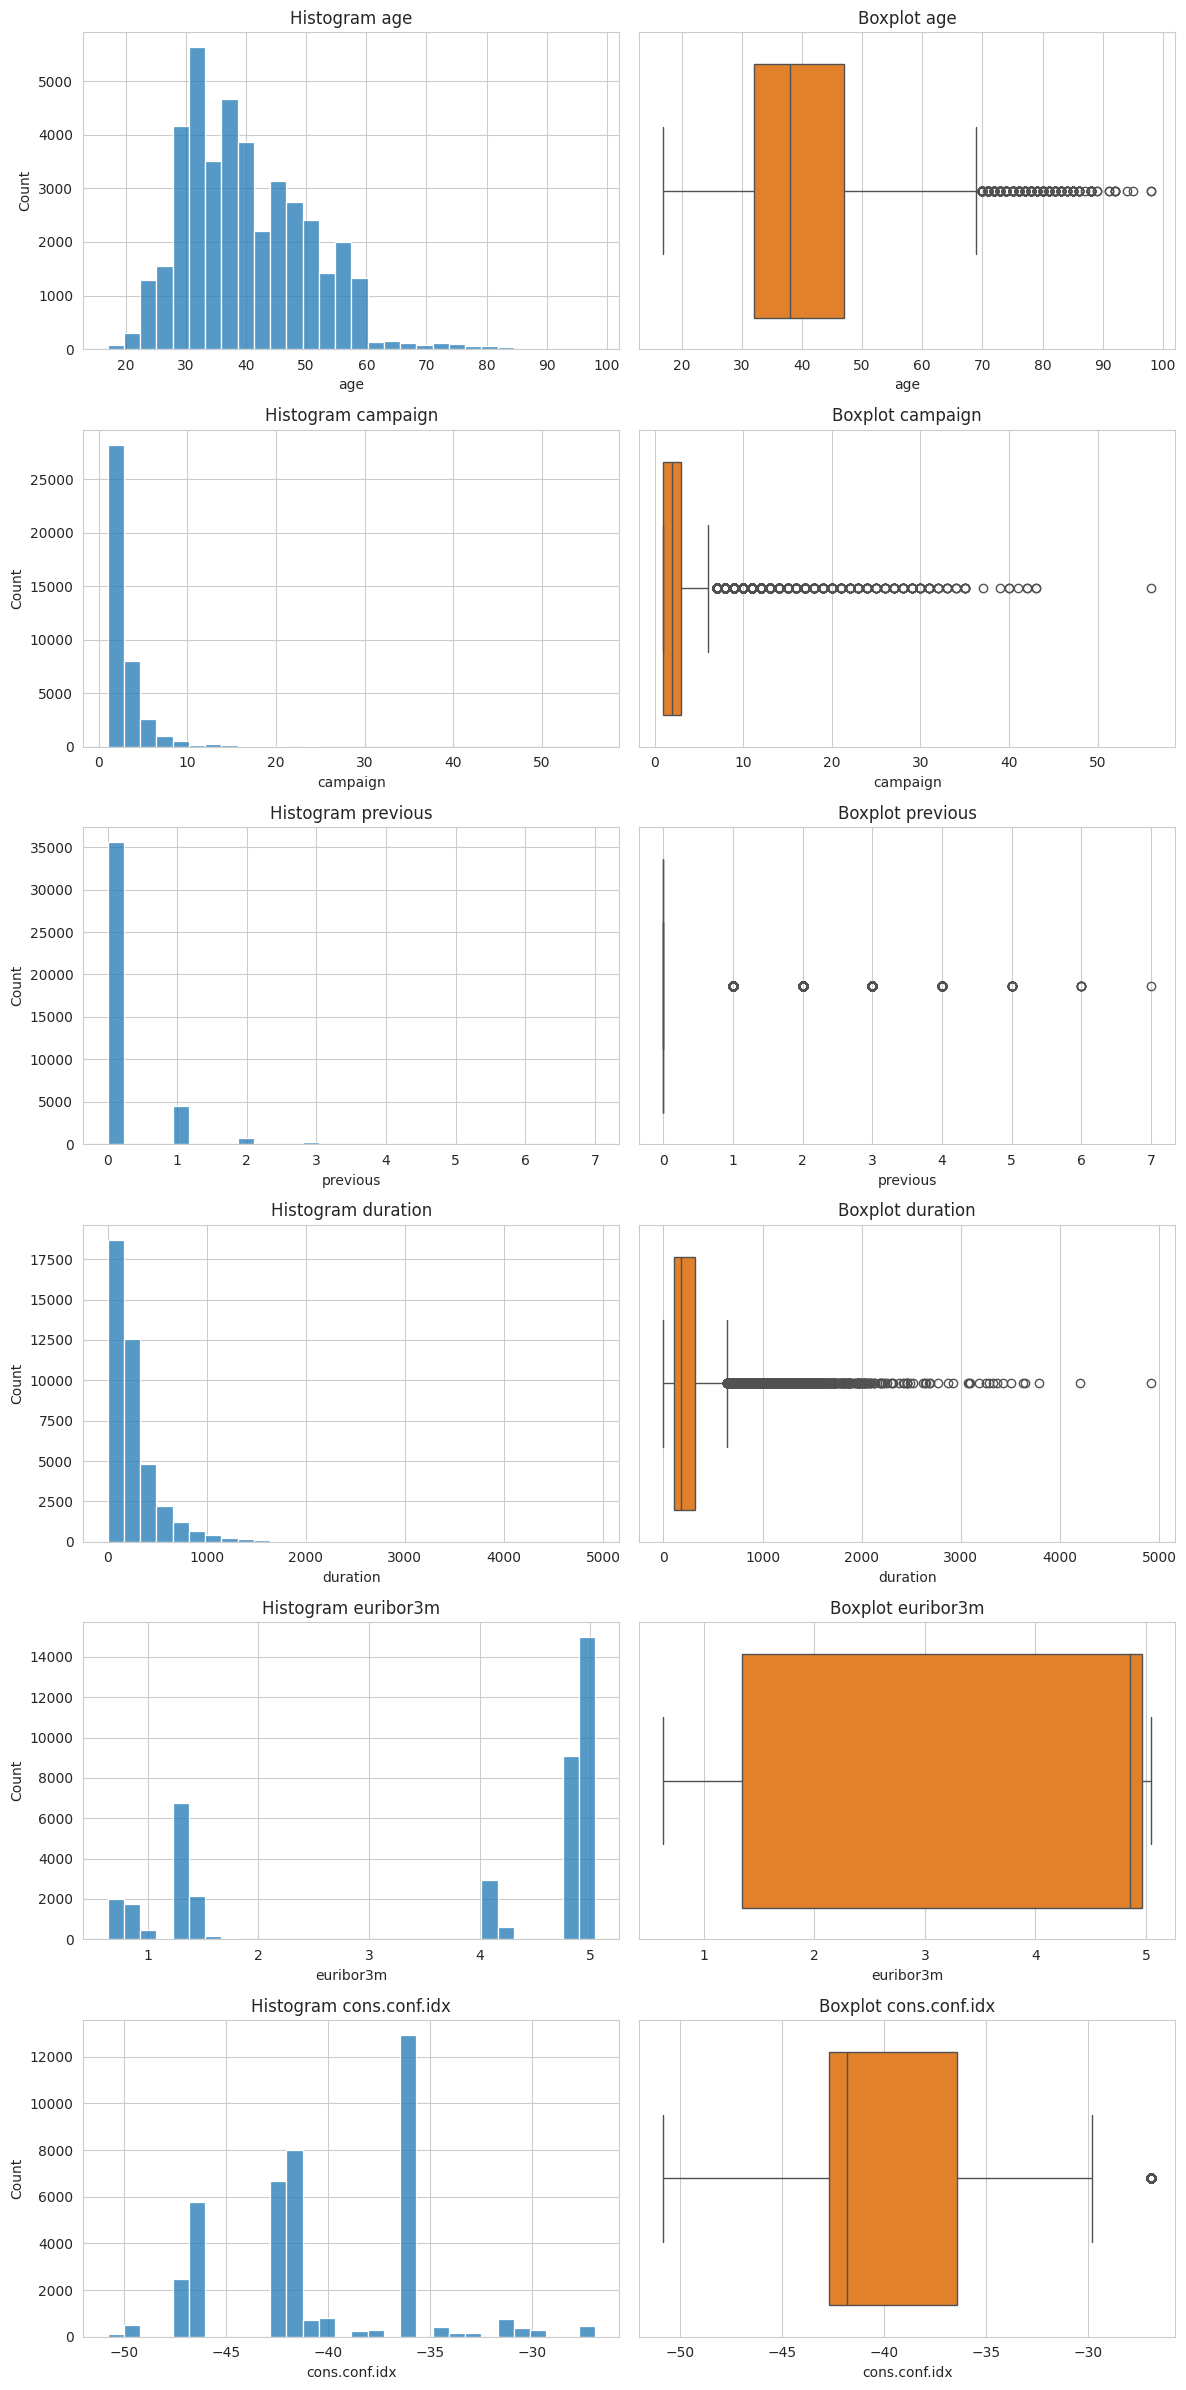

               age      campaign      previous      duration     euribor3m  cons.conf.idx
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   41188.000000
mean      40.02406      2.567593      0.172963    258.285010      3.621291     -40.502600
std       10.42125      2.770014      0.494901    259.279249      1.734447       4.628198
min       17.00000      1.000000      0.000000      0.000000      0.634000     -50.800000
25%       32.00000      1.000000      0.000000    102.000000      1.344000     -42.700000
50%       38.00000      2.000000      0.000000    180.000000      4.857000     -41.800000
75%       47.00000      3.000000      0.000000    319.000000      4.961000     -36.400000
max       98.00000     56.000000      7.000000   4918.000000      5.045000     -26.900000


In [6]:
kolom_numerik_distribusi = ['age', 'campaign', 'previous', 'duration', 'euribor3m', 'cons.conf.idx']

fig, axes = plt.subplots(len(kolom_numerik_distribusi), 2, figsize=(12, 4 * len(kolom_numerik_distribusi)))
for i, col in enumerate(kolom_numerik_distribusi):
    sns.histplot(df_time[col], bins=30, ax=axes[i, 0], color='#1f77b4')
    axes[i, 0].set_title(f'Histogram {col}')
    sns.boxplot(x=df_time[col], ax=axes[i, 1], color='#ff7f0e')
    axes[i, 1].set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

print(df_time[kolom_numerik_distribusi].describe())

### Uji Normalitas: Skewness, Kurtosis, dan Shapiro-Wilk

Sebelum memilih uji statistik untuk membandingkan kelompok nanti, perlu dipastikan dulu apakah kolom numerik utama berdistribusi normal atau tidak. Kalau tidak normal, uji-t tidak valid dipakai dan harus diganti dengan Mann-Whitney U.

In [7]:
kolom_cek_normalitas = ['age', 'euribor3m', 'cons.price.idx']

for col in kolom_cek_normalitas:
    skew = df_time[col].skew()
    kurt = df_time[col].kurt()
    sample = df_time[col].sample(min(5000, len(df_time)), random_state=RANDOM_STATE)
    stat, p = stats.shapiro(sample)
    kesimpulan = 'TIDAK normal -> gunakan Mann-Whitney' if p < 0.05 else 'normal -> uji-t boleh dipakai'
    print(f"{col}:")
    print(f"  skewness = {skew:.3f}, kurtosis = {kurt:.3f}")
    print(f"  Shapiro-Wilk p-value = {p:.4g} -> {kesimpulan}\n")

age:
  skewness = 0.785, kurtosis = 0.791
  Shapiro-Wilk p-value = 1.547e-34 -> TIDAK normal -> gunakan Mann-Whitney

euribor3m:
  skewness = -0.709, kurtosis = -1.407
  Shapiro-Wilk p-value = 1.675e-70 -> TIDAK normal -> gunakan Mann-Whitney

cons.price.idx:
  skewness = -0.231, kurtosis = -0.830
  Shapiro-Wilk p-value = 7.601e-43 -> TIDAK normal -> gunakan Mann-Whitney



### Distribusi Kolom Kategorikal dan Label

Melihat proporsi tiap kategori untuk kolom kategorikal utama, serta proporsi kelas pada label — ini juga langkah awal untuk menilai seberapa seimbang data sebelum masuk ke tahap modeling.

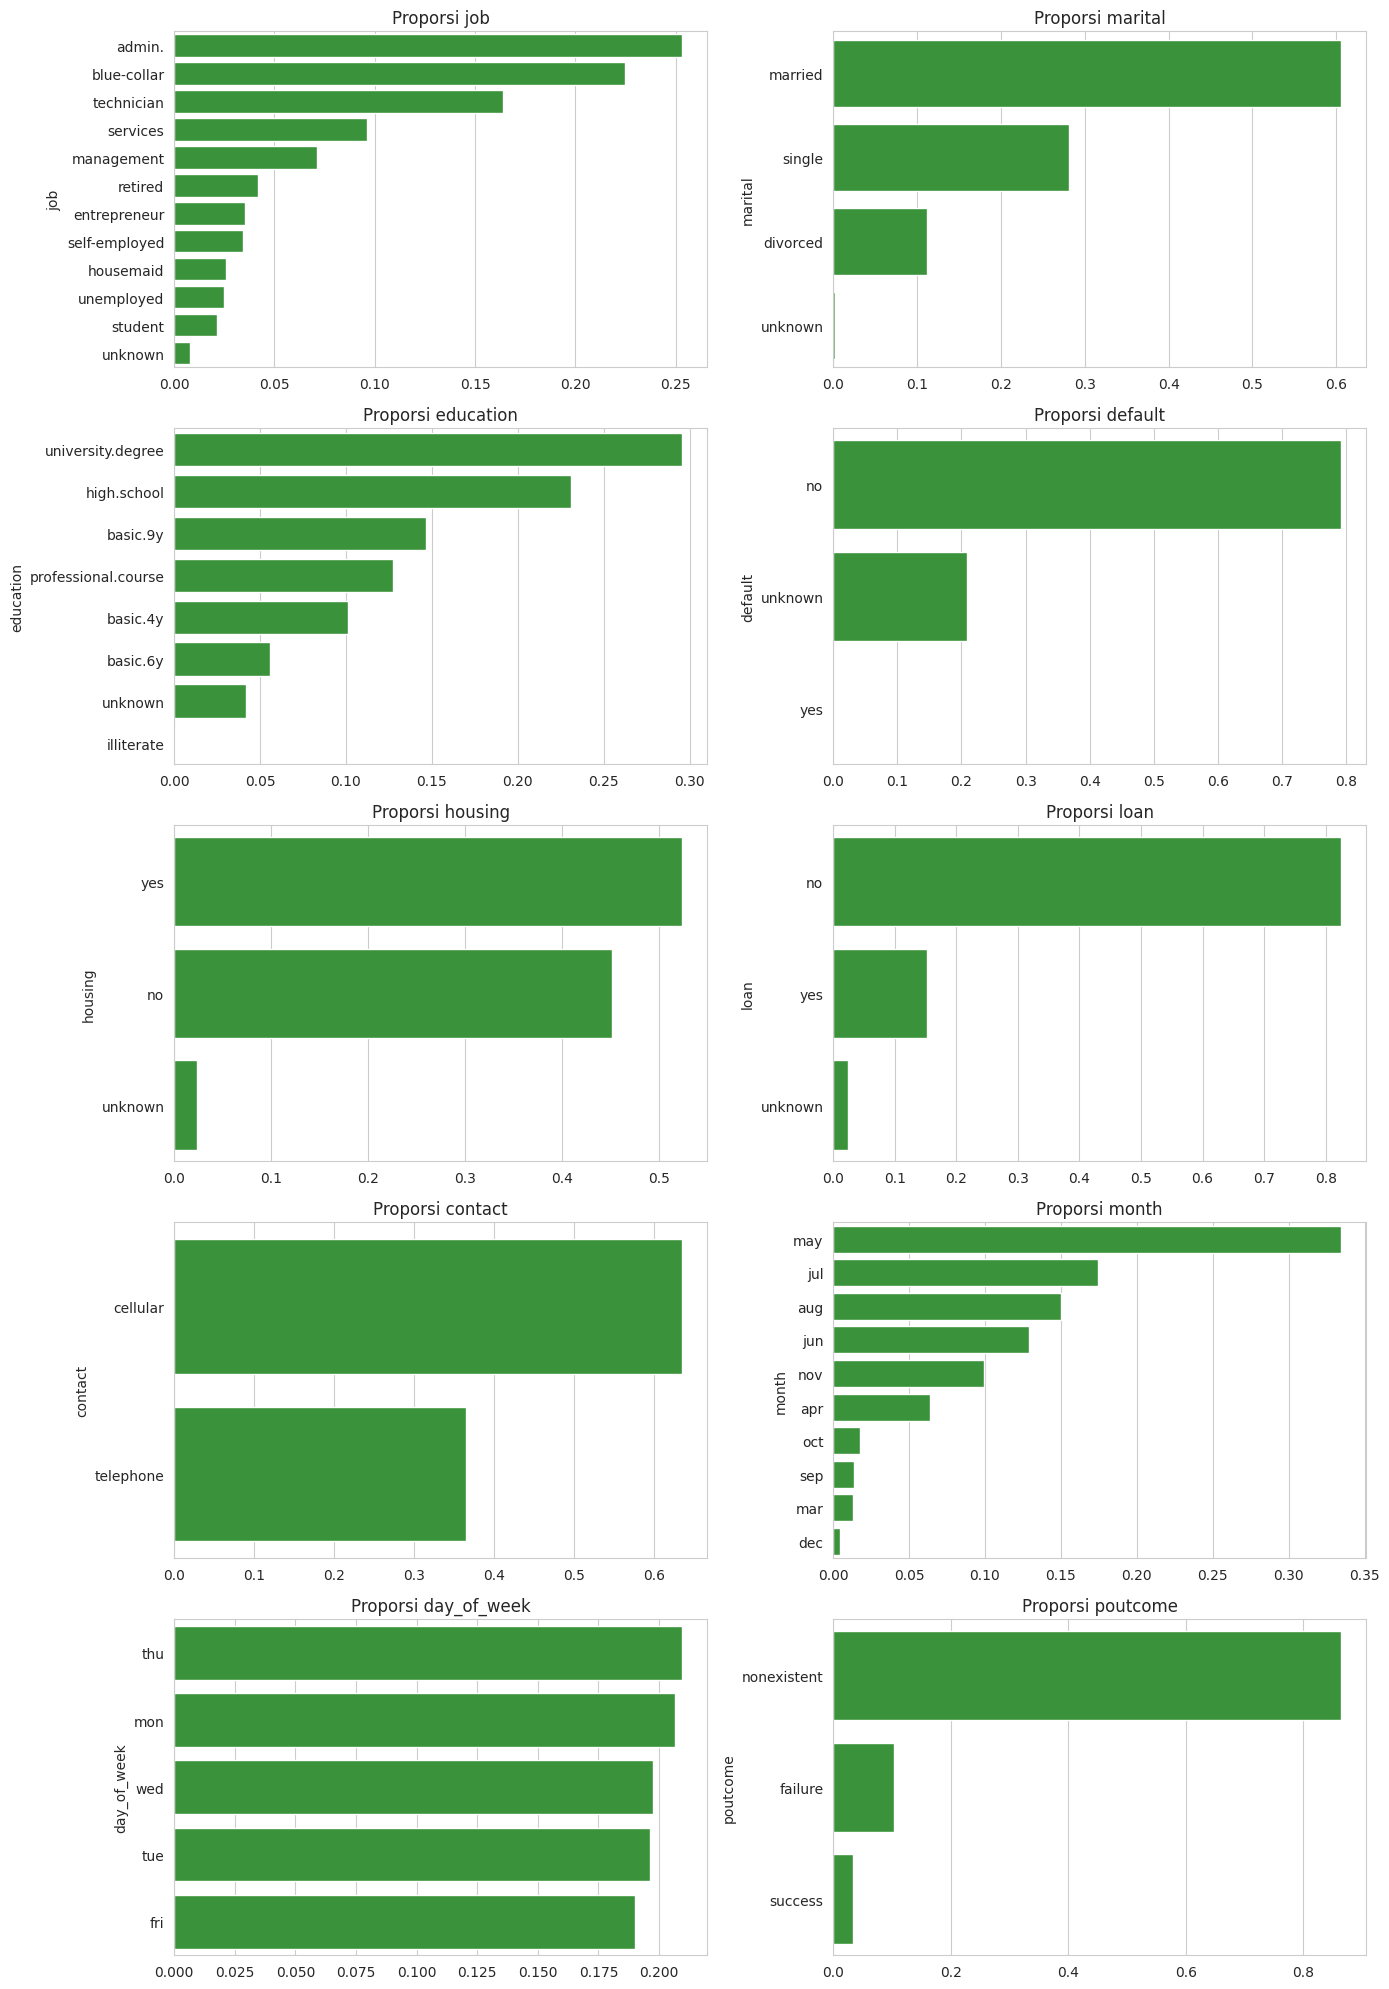

=== Proporsi tiap kolom kategorikal ===

job:
job
admin.           0.2530
blue-collar      0.2247
technician       0.1637
services         0.0964
management       0.0710
retired          0.0418
entrepreneur     0.0354
self-employed    0.0345
housemaid        0.0257
unemployed       0.0246
student          0.0212
unknown          0.0080
Name: proportion, dtype: float64

marital:
marital
married     0.6052
single      0.2809
divorced    0.1120
unknown     0.0019
Name: proportion, dtype: float64

education:
education
university.degree      0.2954
high.school            0.2310
basic.9y               0.1468
professional.course    0.1273
basic.4y               0.1014
basic.6y               0.0556
unknown                0.0420
illiterate             0.0004
Name: proportion, dtype: float64

default:
default
no         0.7912
unknown    0.2087
yes        0.0001
Name: proportion, dtype: float64

housing:
housing
yes        0.5238
no         0.4521
unknown    0.0240
Name: proportion, dtype: float

In [8]:
kolom_kategorikal_plot = ['job', 'marital', 'education', 'default', 'housing',
                          'loan', 'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()
for i, col in enumerate(kolom_kategorikal_plot):
    proporsi = df_time[col].value_counts(normalize=True).sort_values(ascending=False)
    sns.barplot(x=proporsi.values, y=proporsi.index, ax=axes[i], color='#2ca02c')
    axes[i].set_title(f'Proporsi {col}')
plt.tight_layout()
plt.show()

print("=== Proporsi tiap kolom kategorikal ===")
for col in kolom_kategorikal_plot:
    print(f"\n{col}:")
    print(df_time[col].value_counts(normalize=True).round(4))

print("\n=== Distribusi label ===")
print(df_time['y'].value_counts(normalize=True).round(4))

### Signifikansi Hubungan Kategorikal: Chi-Square

Cramér's V menunjukkan kekuatan hubungan, tapi belum menunjukkan apakah hubungan itu signifikan secara statistik atau bisa jadi kebetulan. Uji chi-square melengkapi ini dengan p-value.

In [9]:
hasil_chi2 = []
for col in kolom_kategorikal:
    tabel = pd.crosstab(df_time[col], df_time['y'])
    chi2, p_value, dof, _ = chi2_contingency(tabel)
    cv = cramers_v(df_time[col], df_time['y'])
    hasil_chi2.append({
        'kolom': col, 'cramers_v': round(cv, 3),
        'chi2': round(chi2, 2), 'dof': dof, 'p_value': p_value,
        'signifikan_0.05': p_value < 0.05
    })

tabel_chi2 = pd.DataFrame(hasil_chi2).sort_values('cramers_v', ascending=False)
print(tabel_chi2.to_string(index=False))

      kolom  cramers_v    chi2  dof       p_value  signifikan_0.05
   poutcome      0.320 4230.52    2  0.000000e+00             True
      month      0.274 3101.15    9  0.000000e+00             True
        job      0.153  961.24   11 4.189763e-199             True
    contact      0.145  862.32    1 1.525986e-189             True
    default      0.099  406.58    2  5.161958e-89             True
  education      0.068  193.11    7  3.305189e-38             True
    marital      0.055  122.66    3  2.068015e-26             True
day_of_week      0.025   26.14    4  2.958482e-05             True
    housing      0.012    5.68    2  5.829448e-02            False
       loan      0.005    1.09    2  5.786753e-01            False


### Korelasi Antar Kolom Numerik dan Pemeriksaan Multikolinearitas

Kolom indikator makro (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) berpotensi saling berkorelasi tinggi karena sama-sama mencerminkan kondisi ekonomi pada periode yang sama. Kalau benar, ini berpengaruh ke pemilihan model nanti — model linear akan kesulitan menginterpretasi koefisien masing-masing kalau sudah saling tumpang tindih.

=== Korelasi Pearson ===
                  age  campaign  pdays  previous  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
age             1.000     0.005 -0.034     0.024        -0.000           0.001          0.129      0.011       -0.018
campaign        0.005     1.000  0.053    -0.079         0.151           0.128         -0.014      0.135        0.144
pdays          -0.034     0.053  1.000    -0.588         0.271           0.079         -0.091      0.297        0.373
previous        0.024    -0.079 -0.588     1.000        -0.420          -0.203         -0.051     -0.454       -0.501
emp.var.rate   -0.000     0.151  0.271    -0.420         1.000           0.775          0.196      0.972        0.907
cons.price.idx  0.001     0.128  0.079    -0.203         0.775           1.000          0.059      0.688        0.522
cons.conf.idx   0.129    -0.014 -0.091    -0.051         0.196           0.059          1.000      0.278        0.101
euribor3m       0.011     0.135

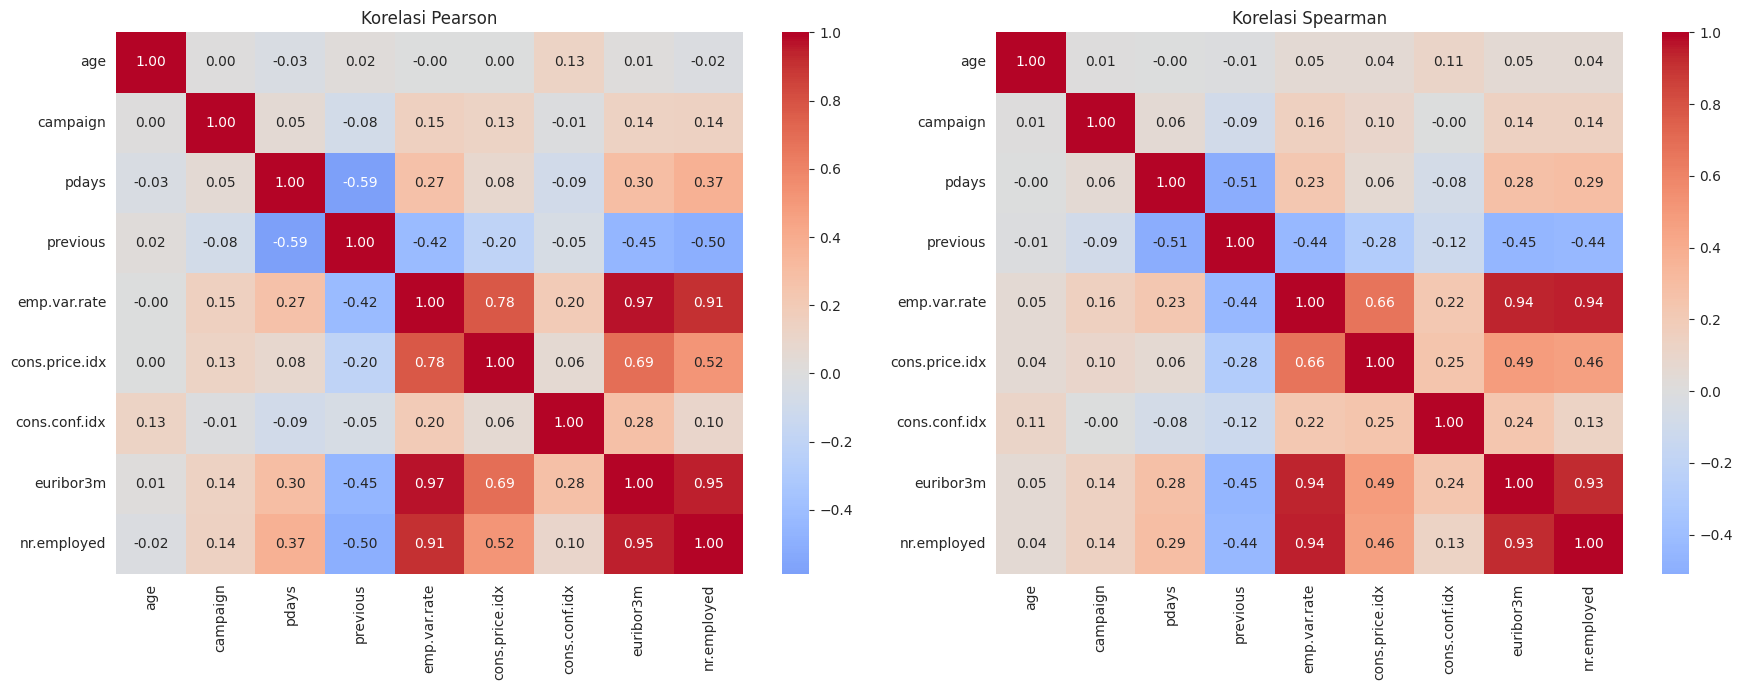


=== Pasangan dengan |r| > 0.8 (indikasi multikolinearitas kuat) ===
  emp.var.rate <-> euribor3m: r = 0.972
  emp.var.rate <-> nr.employed: r = 0.907
  euribor3m <-> nr.employed: r = 0.945

=== Korelasi point-biserial terhadap label ===
  age             : r = +0.030  (p = 6.802e-10)
  campaign        : r = -0.066  (p = 2.008e-41)
  pdays           : r = -0.325  (p = 0)
  previous        : r = +0.230  (p = 0)
  emp.var.rate    : r = -0.298  (p = 0)
  cons.price.idx  : r = -0.136  (p = 9.319e-170)
  cons.conf.idx   : r = +0.055  (p = 7.537e-29)
  euribor3m       : r = -0.308  (p = 0)
  nr.employed     : r = -0.355  (p = 0)


In [10]:
kolom_numerik_semua = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
                       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

corr_pearson = df_time[kolom_numerik_semua].corr(method='pearson')
print("=== Korelasi Pearson ===")
print(corr_pearson.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Korelasi Pearson')
corr_spearman = df_time[kolom_numerik_semua].corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Korelasi Spearman')
plt.tight_layout()
plt.show()

print("\n=== Pasangan dengan |r| > 0.8 (indikasi multikolinearitas kuat) ===")
for i in range(len(kolom_numerik_semua)):
    for j in range(i + 1, len(kolom_numerik_semua)):
        r = corr_pearson.iloc[i, j]
        if abs(r) > 0.8:
            print(f"  {kolom_numerik_semua[i]} <-> {kolom_numerik_semua[j]}: r = {r:.3f}")

print("\n=== Korelasi point-biserial terhadap label ===")
for col in kolom_numerik_semua:
    r, p = pointbiserialr(df_time['label_biner'], df_time[col])
    print(f"  {col:16s}: r = {r:+.3f}  (p = {p:.4g})")

### Pemeriksaan Missing Value, Duplikat, dan Anomali

Mengecek tiga hal: proporsi kategori "unknown" di tiap kolom (apakah nilainya informatif atau sekadar noise), keberadaan baris duplikat identik, dan konsistensi internal antara `pdays` dan `poutcome`.

In [11]:
kolom_ada_unknown = [c for c in kolom_kategorikal if 'unknown' in df_time[c].unique()]
print("=== Conversion rate per nilai, untuk kolom yang punya kategori 'unknown' ===")
for col in kolom_ada_unknown:
    print(f"\n{col}:")
    print(df_time.groupby(col)['label_biner'].agg(['mean', 'size']).round(4))

print("\n=== Duplikat baris identik (seluruh kolom asli) ===")
n_duplikat = df_time.duplicated(subset=df_raw.columns.tolist()).sum()
print(f"Jumlah baris duplikat: {n_duplikat}")
if n_duplikat > 0:
    print(df_time[df_time.duplicated(subset=df_raw.columns.tolist(), keep=False)]
          .sort_values(df_raw.columns.tolist()[0])[['year', 'month', 'age', 'job', 'y']].head(20))

print("\n=== Sentinel pdays=999 dan konsistensinya dengan poutcome ===")
print(f"Proporsi pdays==999: {(df_time['pdays'] == 999).mean():.1%}")
inkonsisten = df_time[(df_time['poutcome'] == 'failure') & (df_time['pdays'] == 999)]
print(f"poutcome=failure tapi pdays=999: {len(inkonsisten)} dari {(df_time['poutcome']=='failure').sum()} baris 'failure'")

print("\n=== Nilai ekstrem campaign ===")
print(f"Max: {df_time['campaign'].max()}, P99: {df_time['campaign'].quantile(0.99):.1f}")

=== Conversion rate per nilai, untuk kolom yang punya kategori 'unknown' ===

job:
                 mean   size
job                         
admin.         0.1297  10422
blue-collar    0.0689   9254
entrepreneur   0.0852   1456
housemaid      0.1000   1060
management     0.1122   2924
retired        0.2523   1720
self-employed  0.1049   1421
services       0.0814   3969
student        0.3143    875
technician     0.1083   6743
unemployed     0.1420   1014
unknown        0.1121    330

marital:
            mean   size
marital                
divorced  0.1032   4612
married   0.1016  24928
single    0.1400  11568
unknown   0.1500     80

education:
                       mean   size
education                         
basic.4y             0.1025   4176
basic.6y             0.0820   2292
basic.9y             0.0782   6045
high.school          0.1084   9515
illiterate           0.2222     18
professional.course  0.1135   5243
university.degree    0.1372  12168
unknown              0.1450   

### Analisis Temporal: Conversion Rate dan Kondisi Makroekonomi per Kuartal

Dengan kolom tahun yang sudah direkonstruksi, langkah berikutnya adalah menguji dugaan paling mendasar dari seluruh analisis ini: apakah variasi conversion rate dari waktu ke waktu benar-benar sejalan dengan perubahan suku bunga acuan, atau sekadar kebetulan.

    quarter_id  year  n_baris  conversion_rate  euribor3m_mean
0            0  2008     7763         0.030916        4.857663
1            1  2008    16234         0.053345        4.954544
2            2  2008     3683         0.062992        4.129610
3            3  2008       10         0.100000        3.493400
4            4  2009     8534         0.127959        1.339254
5            5  2009     1663         0.357186        1.051574
6            6  2009     1071         0.423903        0.740901
7            7  2009      172         0.511628        0.712523
8            8  2010      650         0.567692        0.659134
9            9  2010      773         0.521345        0.830157
10          10  2010      635         0.474016        0.949876


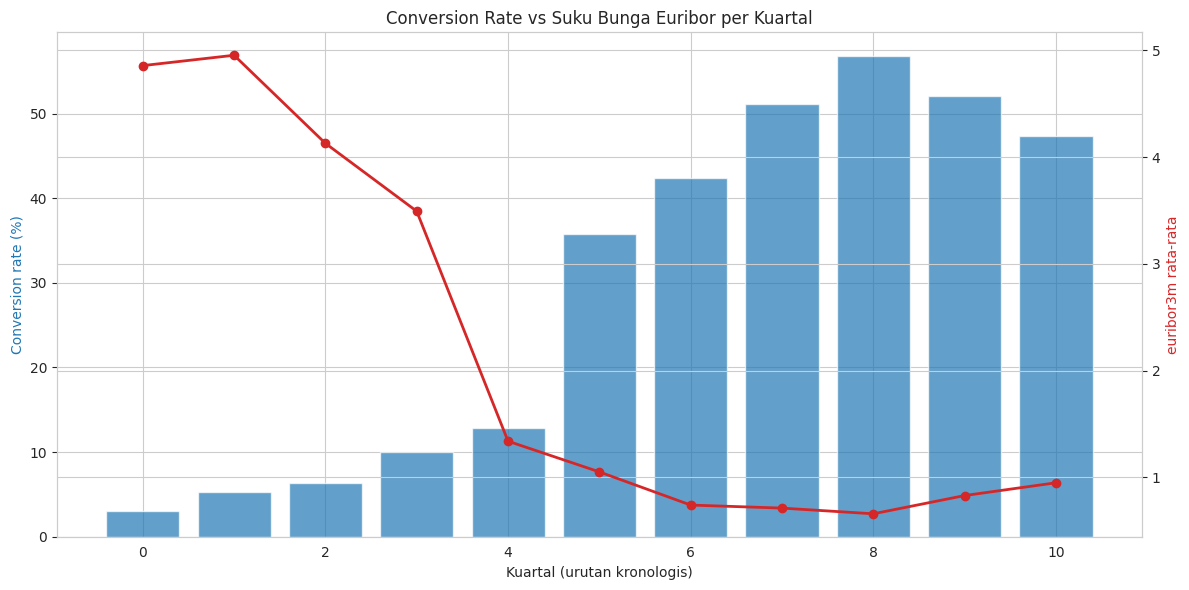


Korelasi conversion_rate dengan euribor3m_mean antar kuartal: -0.886


In [12]:
agg_kuartal = df_time.groupby('quarter_id').agg(
    year=('year', 'first'),
    n_baris=('label_biner', 'size'),
    conversion_rate=('label_biner', 'mean'),
    euribor3m_mean=('euribor3m', 'mean'),
).reset_index()
print(agg_kuartal)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(agg_kuartal['quarter_id'], agg_kuartal['conversion_rate'] * 100, color='#1f77b4', alpha=0.7)
ax1.set_xlabel('Kuartal (urutan kronologis)')
ax1.set_ylabel('Conversion rate (%)', color='#1f77b4')
ax2 = ax1.twinx()
ax2.plot(agg_kuartal['quarter_id'], agg_kuartal['euribor3m_mean'], color='#d62728', marker='o', linewidth=2)
ax2.set_ylabel('euribor3m rata-rata', color='#d62728')
plt.title('Conversion Rate vs Suku Bunga Euribor per Kuartal')
plt.tight_layout()
plt.show()

print("\nKorelasi conversion_rate dengan euribor3m_mean antar kuartal:",
      agg_kuartal['conversion_rate'].corr(agg_kuartal['euribor3m_mean']).round(3))

### Menguji Pseudo-Musiman: Apakah Lonjakan Bulan Tertentu Benar Pola Musiman?

Volume panggilan antar bulan sangat tidak merata, dan beberapa bulan mungkin hanya muncul di tahun-tahun tertentu. Kalau benar, kesimpulan semacam "conversion bulan Maret tinggi" sebenarnya keliru — yang sebenarnya terjadi adalah bulan itu kebetulan hanya tercatat di periode suku bunga rendah.

In [13]:
crosstab_bulan_tahun = pd.crosstab(df_time['month'], df_time['year'])
print(crosstab_bulan_tahun)

print("\nConversion rate per bulan (keseluruhan, tanpa dipisah tahun):")
print(df_time.groupby('month')['label_biner'].agg(['mean', 'size']).round(4).sort_values('mean', ascending=False))

tahun_pertama = crosstab_bulan_tahun.columns[0]
bulan_kosong_tahun_pertama = crosstab_bulan_tahun[crosstab_bulan_tahun.iloc[:, 0] == 0].index.tolist()
print(f"\nBulan yang tidak punya satu baris pun di tahun {tahun_pertama}: {bulan_kosong_tahun_pertama}")

year   2008  2009  2010
month                  
apr       0  2458   174
aug    5175   770   233
dec      10   172     0
jul    6685   178   311
jun    4374   715   229
mar       0   282   264
may    7763  5794   212
nov    3616   357   128
oct      67   447   204
sep       0   267   303

Conversion rate per bulan (keseluruhan, tanpa dipisah tahun):
         mean   size
month               
mar    0.5055    546
dec    0.4890    182
sep    0.4491    570
oct    0.4387    718
apr    0.2048   2632
aug    0.1060   6178
jun    0.1051   5318
nov    0.1014   4101
jul    0.0905   7174
may    0.0643  13769

Bulan yang tidak punya satu baris pun di tahun 2008: ['apr', 'mar', 'sep']


## 4. Preprocessing

### 4.1 Log Masalah Kualitas Data

Merangkum seluruh temuan dari tahap Data Understanding dan EDA menjadi daftar keputusan penanganan yang eksplisit, beserta alasannya.

In [14]:
log_kualitas_data = pd.DataFrame([
    {'no': 1, 'masalah': '12 baris duplikat identik pada seluruh kolom asli',
     'keputusan': 'Dihapus, mempertahankan kemunculan pertama',
     'alasan': 'Tanpa client ID, baris identik hampir pasti artefak pencatatan'},
    {'no': 2, 'masalah': "Kategori 'unknown' pada enam kolom, terbukti informatif pada default (5,2% vs 12,9%)",
     'keputusan': 'Dipertahankan sebagai kategori tersendiri, tidak diimputasi',
     'alasan': 'Menghapus/mengimputasi menghilangkan sinyal dan merusak keterwakilan sampel'},
    {'no': 3, 'masalah': 'pdays bernilai sentinel 999 pada 96,3% baris',
     'keputusan': 'Diubah menjadi previously_contacted dan pdays_bucket',
     'alasan': '999 bukan besaran hari; dipakai mentah merusak korelasi dan skala model'},
    {'no': 4, 'masalah': '4.110 dari 4.252 baris poutcome=failure punya pdays=999 (inkonsisten)',
     'keputusan': 'Perlakukan pdays sebagai recency hanya bila diketahui, acu poutcome/previous',
     'alasan': 'Sentinel 999 tampaknya juga mencakup kontak lama/tidak tercatat'},
    {'no': 5, 'masalah': 'Volume panggilan antar bulan timpang, month ternyata pseudo-musiman (efek periode)',
     'keputusan': 'month dipertahankan sebagai fitur tapi selalu dikontrol per year saat ditarik kesimpulan',
     'alasan': 'Terbukti: April absen 2008 tapi conversion rendah, Maret/September absen 2008 tapi conversion tinggi -- murni efek distribusi kuartal'},
    {'no': 6, 'masalah': 'duration median 449 detik (yes) vs 163,5 detik (no) -- leakage',
     'keputusan': 'Dikeluarkan dari daftar fitur model, disimpan sebagai duration_s untuk deskriptif',
     'alasan': 'Durasi baru diketahui setelah panggilan selesai'},
    {'no': 7, 'masalah': "default=yes cuma 3 baris (0,01%), education=illiterate cuma 18 baris (0,04%)",
     'keputusan': "default: gabung 'yes' ke 'unknown'. education: dipertahankan karena di-encode ordinal, bukan one-hot",
     'alasan': 'Observasi terlalu sedikit untuk menopang kategori one-hot sendiri'},
    {'no': 8, 'masalah': 'campaign punya nilai ekstrem (max 56, P99 cuma 14)',
     'keputusan': 'Dipertahankan apa adanya untuk model, dibatasi hanya untuk visualisasi',
     'alasan': 'Nilai ekstrem adalah perilaku nyata (pola conversion menurun seiring jumlah panggilan)'},
    {'no': 9, 'masalah': 'emp.var.rate, euribor3m, nr.employed, cons.price.idx saling kolinear tinggi (r 0,69-0,97)',
     'keputusan': 'Model pohon/regularisasi; untuk interpretasi linear pilih euribor3m sebagai representasi',
     'alasan': 'Koefisien linear individual tidak bisa diinterpretasikan saat kolinearitas setinggi ini'},
    {'no': 10, 'masalah': 'nr.employed cuma 11 nilai unik, korelasi terkuat ke label (-0,355) justru karena jadi penanda kuartal',
     'keputusan': 'Dipakai merekonstruksi year, lalu dikeluarkan dari daftar fitur model',
     'alasan': 'Jika dibiarkan, model belajar periode waktu, bukan perilaku nasabah'},
    {'no': 11, 'masalah': 'pdays dan previous berkorelasi -0,588, sebagian besar artefak dari sentinel 999',
     'keputusan': 'pdays mentah tidak dipakai langsung; digantikan pdays_bucket',
     'alasan': 'Korelasi ini bukan pola bisnis murni, melainkan konsekuensi cara sentinel dikodekan'},
])
print(log_kualitas_data.to_string(index=False))

 no                                                                                               masalah                                                                                            keputusan                                                                                                                                alasan
  1                                                     12 baris duplikat identik pada seluruh kolom asli                                                           Dihapus, mempertahankan kemunculan pertama                                                                        Tanpa client ID, baris identik hampir pasti artefak pencatatan
  2                  Kategori 'unknown' pada enam kolom, terbukti informatif pada default (5,2% vs 12,9%)                                          Dipertahankan sebagai kategori tersendiri, tidak diimputasi                                                           Menghapus/mengimputasi menghilangkan sinyal dan merus

### 4.2 Pembersihan dan Penyesuaian Tipe Data

Mengeksekusi sebagian keputusan di log: menghapus duplikat, menyeragamkan nama kolom, mengubah label menjadi numerik, dan menetapkan `month`/`day_of_week` sebagai kategori berurutan supaya nanti tidak terbaca alfabetis saat divisualisasikan.

In [15]:
df_clean = df_time.drop(columns=['month_rank', 'quarter_id']).copy()

# Seragamkan nama kolom bertitik menjadi snake_case
df_clean.columns = df_clean.columns.str.replace('.', '_', regex=False)

# Hapus duplikat (Log #1), pertahankan kemunculan pertama
kolom_asli = [c for c in df_clean.columns if c not in ('year', 'label_biner')]
n_sebelum = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=kolom_asli, keep='first').reset_index(drop=True)
print(f"Baris sebelum: {n_sebelum}, sesudah: {len(df_clean)} ({n_sebelum - len(df_clean)} dihapus)")

# Label y -> subscribed (0/1)
df_clean['subscribed'] = (df_clean['y'] == 'yes').astype(int)
df_clean = df_clean.drop(columns=['label_biner'])

# month & day_of_week sebagai ordered categorical
month_order_cat = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dow_order_cat = ['mon','tue','wed','thu','fri']
df_clean['month'] = pd.Categorical(df_clean['month'], categories=month_order_cat, ordered=True)
df_clean['day_of_week'] = pd.Categorical(df_clean['day_of_week'], categories=dow_order_cat, ordered=True)

# duration disimpan sebagai duration_s (khusus deskriptif, bukan fitur model -- Log #6)
df_clean = df_clean.rename(columns={'duration': 'duration_s'})

print("\nKolom setelah pembersihan:")
print(df_clean.columns.tolist())
print("\nShape akhir:", df_clean.shape)
print("\nValidasi proporsi label setelah dibersihkan:")
print(df_clean['subscribed'].value_counts(normalize=True).round(4))

Baris sebelum: 41188, sesudah: 41176 (12 dihapus)

Kolom setelah pembersihan:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration_s', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'year', 'subscribed']

Shape akhir: (41176, 23)

Validasi proporsi label setelah dibersihkan:
subscribed
0    0.8873
1    0.1127
Name: proportion, dtype: float64


### 4.3 Pembentukan Fitur Turunan

Mengubah pdays yang bernilai sentinel menjadi dua fitur yang lebih bermakna (previously_contacted dan pdays_bucket), serta menyiapkan age_group dan campaign_bucket untuk kebutuhan analisis deskriptif/segmentasi nanti. Juga menyederhanakan kategori default yang observasinya terlalu sedikit.

In [16]:
# previously_contacted & pdays_bucket (Log #3, #11)
df_clean['previously_contacted'] = np.where(df_clean['pdays'] == 999, 'tidak', 'ya')

def bucket_pdays(p):
    if p == 999:
        return 'belum_pernah'
    elif p <= 3:
        return '0-3_hari'
    elif p <= 7:
        return '4-7_hari'
    else:
        return '8+_hari'

df_clean['pdays_bucket'] = pd.Categorical(
    df_clean['pdays'].apply(bucket_pdays),
    categories=['0-3_hari', '4-7_hari', '8+_hari', 'belum_pernah'], ordered=True
)

# age_group untuk analisis deskriptif segmentasi usia
def bucket_age(a):
    if a < 30: return '<30'
    elif a < 46: return '30-45'
    elif a < 60: return '46-59'
    else: return '60+'

df_clean['age_group'] = pd.Categorical(
    df_clean['age'].apply(bucket_age),
    categories=['<30', '30-45', '46-59', '60+'], ordered=True
)

# campaign_bucket untuk analisis deskriptif batas panggilan (Log #8)
def bucket_campaign(c):
    if c <= 3: return str(c)
    elif c <= 5: return '4-5'
    elif c <= 10: return '6-10'
    else: return '11+'

df_clean['campaign_bucket'] = pd.Categorical(
    df_clean['campaign'].apply(bucket_campaign),
    categories=['1', '2', '3', '4-5', '6-10', '11+'], ordered=True
)

# default disederhanakan untuk modeling (Log #7)
print("Distribusi default sebelum disederhanakan:")
print(df_clean['default'].value_counts())
df_clean['default_model'] = np.where(df_clean['default'] == 'yes', 'unknown', df_clean['default'])
print("\nDistribusi default_model sesudah:")
print(df_clean['default_model'].value_counts())

print("\nValidasi previously_contacted vs pdays_bucket (cek konsistensi):")
print(pd.crosstab(df_clean['previously_contacted'], df_clean['pdays_bucket']))

print("\nContoh 5 baris:")
print(df_clean[['age', 'age_group', 'campaign', 'campaign_bucket', 'pdays', 'previously_contacted', 'pdays_bucket']].head())

Distribusi default sebelum disederhanakan:
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

Distribusi default_model sesudah:
default_model
no         32577
unknown     8599
Name: count, dtype: int64

Validasi previously_contacted vs pdays_bucket (cek konsistensi):
pdays_bucket          0-3_hari  4-7_hari  8+_hari  belum_pernah
previously_contacted                                           
tidak                        0         0        0         39661
ya                         541       636      338             0

Contoh 5 baris:
   age age_group  campaign campaign_bucket  pdays previously_contacted  pdays_bucket
0   56     46-59         1               1    999                tidak  belum_pernah
1   57     46-59         1               1    999                tidak  belum_pernah
2   37     30-45         1               1    999                tidak  belum_pernah
3   40     30-45         1               1    999                tidak  belum_pernah

### 4.4 Encoding dan Penskalaan

Membagi data berdasarkan tahun (latih 2008–2009, uji 2010) untuk mensimulasikan penggunaan nyata di masa depan, lalu melatih encoder dan scaler hanya pada data latih sebelum diterapkan ke data uji. Membalik urutan ini (fit sebelum split) akan membuat skor evaluasi nanti tidak bisa dipercaya karena data uji ikut "terlihat" saat transformer dilatih.

In [17]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

train_df = df_clean[df_clean['year'] <= 2009].copy()
test_df = df_clean[df_clean['year'] == 2010].copy()

print(f"Data latih (2008-2009): {train_df.shape[0]} baris, conversion {train_df['subscribed'].mean():.2%}")
print(f"Data uji (2010): {test_df.shape[0]} baris, conversion {test_df['subscribed'].mean():.2%}")

kolom_ordinal = ['education']
urutan_education = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                      'professional.course', 'university.degree', 'unknown']]

kolom_onehot = ['job', 'marital', 'contact', 'month', 'day_of_week', 'poutcome', 'default_model']
kolom_numerik_scaling = ['age', 'campaign', 'previous', 'emp_var_rate',
                          'cons_price_idx', 'cons_conf_idx', 'euribor3m']

preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=urutan_education,
                                handle_unknown='use_encoded_value', unknown_value=-1),
     kolom_ordinal),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), kolom_onehot),
    ('scaler', StandardScaler(), kolom_numerik_scaling),
], remainder='passthrough')

kolom_dipakai = kolom_ordinal + kolom_onehot + kolom_numerik_scaling
X_train_encoded = preprocessor.fit_transform(train_df[kolom_dipakai])
X_test_encoded = preprocessor.transform(test_df[kolom_dipakai])

print(f"\nJumlah kolom sebelum encoding: {len(kolom_dipakai)}")
print(f"Jumlah kolom sesudah encoding: {len(preprocessor.get_feature_names_out())}")
print(f"Shape X_train: {X_train_encoded.shape}, X_test: {X_test_encoded.shape}")

Data latih (2008-2009): 39118 baris, conversion 9.12%
Data uji (2010): 2058 baris, conversion 52.14%

Jumlah kolom sebelum encoding: 15
Jumlah kolom sesudah encoding: 46
Shape X_train: (39118, 46), X_test: (2058, 46)


### 4.5 Pendefinisian Daftar Fitur Model secara Eksplisit

Merangkum seluruh keputusan dari log kualitas data menjadi satu daftar fitur final yang akan dipakai untuk modeling nanti, beserta alasan setiap kolom yang dikeluarkan.

In [18]:
FEATURE_COLS = [
    # Profil nasabah
    'age', 'job', 'marital', 'education', 'default_model',
    # Riwayat kontak & kampanye
    'contact', 'month', 'day_of_week', 'campaign',
    'previously_contacted', 'pdays_bucket', 'previous', 'poutcome',
    # Indikator makro
    'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m',
    # Dimensi waktu hasil rekonstruksi
    'year',
]

KOLOM_DIKELUARKAN = {
    'duration_s': 'Leakage -- baru diketahui setelah panggilan selesai (Log #6)',
    'housing': 'Tidak signifikan secara statistik (chi-square p=0.058)',
    'loan': 'Tidak signifikan secara statistik (chi-square p=0.579)',
    'nr_employed': 'Korelasi terkuat ke label justru karena jadi penanda kuartal, redundan dengan year (Log #10)',
    'pdays': 'Digantikan previously_contacted & pdays_bucket (Log #3, #11)',
    'default': 'Digantikan default_model (Log #7)',
    'y': 'Label mentah -- digantikan subscribed',
}

print(f"Jumlah fitur model final: {len(FEATURE_COLS)}")
for f in FEATURE_COLS:
    print(f"  - {f}")

print("\nKolom yang dikeluarkan beserta alasannya:")
for k, v in KOLOM_DIKELUARKAN.items():
    print(f"  - {k}: {v}")

kolom_hilang = [f for f in FEATURE_COLS if f not in df_clean.columns]
assert not kolom_hilang, f"Fitur belum tersedia: {kolom_hilang}"
print("\nValidasi: seluruh fitur tersedia di df_clean. OK.")

Jumlah fitur model final: 18
  - age
  - job
  - marital
  - education
  - default_model
  - contact
  - month
  - day_of_week
  - campaign
  - previously_contacted
  - pdays_bucket
  - previous
  - poutcome
  - emp_var_rate
  - cons_price_idx
  - cons_conf_idx
  - euribor3m
  - year

Kolom yang dikeluarkan beserta alasannya:
  - duration_s: Leakage -- baru diketahui setelah panggilan selesai (Log #6)
  - housing: Tidak signifikan secara statistik (chi-square p=0.058)
  - loan: Tidak signifikan secara statistik (chi-square p=0.579)
  - nr_employed: Korelasi terkuat ke label justru karena jadi penanda kuartal, redundan dengan year (Log #10)
  - pdays: Digantikan previously_contacted & pdays_bucket (Log #3, #11)
  - default: Digantikan default_model (Log #7)
  - y: Label mentah -- digantikan subscribed

Validasi: seluruh fitur tersedia di df_clean. OK.


### 4.6 Ekspor Data Bersih

Menyimpan data yang sudah dibersihkan ke file terpisah, supaya tahap analisis deskriptif/inferensial dan modeling berikutnya tidak perlu mengulang seluruh proses cleaning dari awal, dan supaya aturan pembersihan ini "dibekukan" sebelum masuk ke tahap modeling.

In [19]:
import os

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Purwadhika_FinPro/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_clean.to_csv(f'{OUTPUT_DIR}/bank_clean.csv', index=False)
print(f"bank_clean.csv tersimpan -- {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")

agg_kuartal.to_csv(f'{OUTPUT_DIR}/agg_conversion_by_period.csv', index=False)
print(f"agg_conversion_by_period.csv tersimpan -- {agg_kuartal.shape[0]} baris")

log_kualitas_data.to_csv(f'{OUTPUT_DIR}/log_kualitas_data.csv', index=False)
print("log_kualitas_data.csv tersimpan")

with open(f'{OUTPUT_DIR}/feature_list.txt', 'w') as f:
    f.write("FEATURE_COLS:\n")
    for feat in FEATURE_COLS:
        f.write(f"  - {feat}\n")
    f.write("\nKolom dikeluarkan:\n")
    for k, v in KOLOM_DIKELUARKAN.items():
        f.write(f"  - {k}: {v}\n")
print("feature_list.txt tersimpan")

print("\n=== Ringkasan akhir ===")
print(f"Data bersih: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")
print(f"Fitur model: {len(FEATURE_COLS)} kolom")
print(f"Split: latih {train_df.shape[0]} baris / uji {test_df.shape[0]} baris")

bank_clean.csv tersimpan -- 41176 baris x 28 kolom
agg_conversion_by_period.csv tersimpan -- 11 baris
log_kualitas_data.csv tersimpan
feature_list.txt tersimpan

=== Ringkasan akhir ===
Data bersih: 41176 baris x 28 kolom
Fitur model: 18 kolom
Split: latih 39118 baris / uji 2058 baris


## 5. Methodology — Analytics

### 5.1 Kerangka Kerja

**Aturan paradigma deskriptif:**
- Satu grafik memuat satu narasi saja
- Setiap angka conversion rate selalu disertai jumlah observasinya (n) -- tanpa n, itu cherry picking
- Setiap temuan dikontrol per tahun sebelum dinyatakan sebagai kesimpulan umum

**Aturan paradigma inferensial:**
- Hipotesis dirumuskan sebelum pengujian, alpha = 0.05
- Kalau menguji banyak segmen sekaligus, pakai koreksi Bonferroni

**Kerangka DIKIW** (menentukan level kematangan temuan):
- Information/Knowledge: statistik 1-2 variabel, cuma jadi konteks
- Insight: statistik 3+ variabel, belum terhubung ke masalah bisnis
- Wisdom: statistik 3+ variabel, terhubung ke masalah bisnis, dilengkapi rekomendasi -- ini yang jadi headline

**Format penulisan temuan:** Di antara [segmen], kelompok [nama] melakukan conversion [persen] dengan n=[jumlah], yaitu [selisih] poin lebih tinggi/rendah dibanding [pembanding]. Kondisi ini menunjukkan [interpretasi]. Rekomendasi: [tindakan], potensi dampak [estimasi]. Temuan ini bersifat [robust/kondisional].

### 5.2 Pertanyaan Analisis

- Q1: Siapa yang melakukan conversion, dilihat dari usia, pekerjaan, dan pendidikan?
- Q2: Riwayat kontak sebelumnya vs karakteristik demografis, mana yang lebih menentukan?
- Q3: Pada jumlah panggilan berapa hasil mulai menurun, dan di mana batas optimalnya?
- Q4: Segmen mana sebaiknya tidak lagi dihubungi lewat telepon kabel?
- Q5: Durasi panggilan seperti apa yang berkaitan dengan keberhasilan (bahan pelatihan agen)?

### Q1: Siapa yang Melakukan Conversion?

Melihat conversion rate berdasarkan pekerjaan, dikontrol per tahun -- supaya tidak salah menyimpulkan "pekerjaan X bagus" padahal itu cuma kebetulan mayoritas datanya terkumpul di periode suku bunga rendah.

In [20]:
conversion_job_per_year = df_clean.pivot_table(
    index='job', columns='year', values='subscribed', aggfunc=['mean', 'size']
)
print(conversion_job_per_year.round(4))

print("\nConversion rate job keseluruhan (tanpa dipisah tahun), diurutkan:")
print(df_clean.groupby('job')['subscribed'].agg(['mean', 'size']).round(4).sort_values('mean', ascending=False))

                 mean                  size           
year             2008    2009    2010  2008  2009 2010
job                                                   
admin.         0.0492  0.2281  0.5335  6827  2951  641
blue-collar    0.0468  0.1013  0.4926  6471  2646  136
entrepreneur   0.0544  0.1511  0.4231  1066   364   26
housemaid      0.0328  0.2652  0.5636   824   181   55
management     0.0536  0.2003  0.5167  2015   789  120
retired        0.0591  0.3652  0.5474   795   649  274
self-employed  0.0484  0.2048  0.4528   992   376   53
services       0.0485  0.1218  0.4390  2719  1125  123
student        0.0725  0.3214  0.5215   193   473  209
technician     0.0470  0.2152  0.5268  4870  1552  317
unemployed     0.0363  0.2744  0.5465   662   266   86
unknown        0.0524  0.2344  0.5000   248    64   18

Conversion rate job keseluruhan (tanpa dipisah tahun), diurutkan:
                 mean   size
job                         
student        0.3143    875
retired        0.2526

Melengkapi Q1 dengan segmentasi usia, dikontrol per tahun dengan cara yang sama.

In [21]:
conversion_agegroup_per_year = df_clean.pivot_table(
    index='age_group', columns='year', values='subscribed', aggfunc=['mean', 'size']
)
print(conversion_agegroup_per_year.round(4))

print("\nConversion rate age_group keseluruhan:")
print(df_clean.groupby('age_group', observed=True)['subscribed'].agg(['mean', 'size']).round(4))

             mean                   size           
year         2008    2009    2010   2008  2009 2010
age_group                                          
<30        0.0544  0.2379  0.4889   2999  2173  495
30-45      0.0500  0.1562  0.5130  16409  6426  846
46-59      0.0426  0.2043  0.5349   8101  2163  372
60+        0.0578  0.3917  0.5739    173   674  345

Conversion rate age_group keseluruhan:
             mean   size
age_group               
<30        0.1627   5667
30-45      0.0954  23681
46-59      0.0927  10636
60+        0.3960   1192


/tmp/ipykernel_5250/1008150548.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  conversion_agegroup_per_year = df_clean.pivot_table(
/tmp/ipykernel_5250/1008150548.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  conversion_agegroup_per_year = df_clean.pivot_table(


Melengkapi Q1 dengan segmentasi pendidikan, dikontrol per tahun.

In [22]:
conversion_education_per_year = df_clean.pivot_table(
    index='education', columns='year', values='subscribed', aggfunc=['mean', 'size'], observed=True
)
print(conversion_education_per_year.round(4))

print("\nConversion rate education keseluruhan:")
print(df_clean.groupby('education', observed=True)['subscribed'].agg(['mean', 'size']).round(4).sort_values('mean', ascending=False))

                       mean                    size               
year                   2008    2009    2010    2008    2009   2010
education                                                         
basic.4y             0.0375  0.1981  0.5572  2935.0  1040.0  201.0
basic.6y             0.0497  0.1387  0.5455  1609.0   649.0   33.0
basic.9y             0.0493  0.1191  0.4634  4142.0  1780.0  123.0
high.school          0.0498  0.1729  0.5055  6211.0  2846.0  455.0
illiterate           0.0833  0.5000     NaN    12.0     6.0    NaN
professional.course  0.0455  0.2105  0.5270  3647.0  1297.0  296.0
university.degree    0.0525  0.2469  0.5228  7982.0  3394.0  788.0
unknown              0.0437  0.2665  0.5432  1144.0   424.0  162.0

Conversion rate education keseluruhan:
                       mean   size
education                         
illiterate           0.2222     18
unknown              0.1451   1730
university.degree    0.1372  12164
professional.course  0.1135   5240
high.school  

### Insight Q1: Siapa yang Melakukan Conversion?

**Usia.** Di antara empat kelompok usia, kelompok **60+** melakukan conversion tertinggi secara konsisten di tiga tahun (5,78% dari n=173 pada 2008; 39,17% dari n=674 pada 2009; 57,39% dari n=345 pada 2010) -- selalu di peringkat pertama dibanding tiga kelompok usia lain. Namun besaran keunggulannya berubah-ubah (rasio terhadap kelompok lain naik dari ~1,2x di 2008, memuncak ~2,1x di 2009, lalu menyempit lagi ~1,1x di 2010). Kondisi ini menunjukkan bahwa nasabah usia lanjut secara konsisten lebih reseptif terhadap produk term deposit, kemungkinan karena preferensi mereka terhadap instrumen investasi berisiko rendah, namun keunggulan ini paling signifikan ketika suku bunga sedang turun -- saat itulah term deposit menjadi pilihan yang relatif lebih menarik secara kompetitif. Rekomendasi: prioritaskan segmen 60+ sebagai target utama terutama saat tren suku bunga sedang menurun, dengan ekspektasi dampak yang bervariasi tergantung kondisi makro saat itu. **Temuan ini robust pada arah (60+ selalu tertinggi), namun kondisional pada besaran keunggulannya.**

**Pekerjaan.** Di antara dua belas kategori pekerjaan, **blue-collar** secara konsisten berada di kelompok conversion terendah pada ketiga tahun (4,68% n=6.471 pada 2008; 10,13% n=2.646 pada 2009; 49,26% n=136 pada 2010) -- selalu kalah dibanding mayoritas kategori lain. Sebaliknya, kategori seperti `student` dan `retired` yang terlihat unggul pada agregat keseluruhan (31,43% dan 25,26%) ternyata tidak stabil peringkatnya: keduanya dominan di 2008-2009 namun tergeser kategori lain (termasuk `housemaid` yang justru terendah di 2008) pada 2010 -- kemungkinan karena ukuran sampel yang sangat kecil di 2010 (n `housemaid`=55, `entrepreneur`=26). Rekomendasi: turunkan prioritas segmen blue-collar pada call list secara permanen, sementara `student`/`retired` diperlakukan sebagai prioritas kondisional, bukan aturan tetap. **Temuan blue-collar sebagai segmen terendah bersifat robust; urutan kategori di atasnya kondisional.**

**Pendidikan.** Pola berdasarkan pendidikan kurang tegas dibanding usia dan pekerjaan. `basic.9y` cenderung berada di kelompok conversion terendah pada 2009 dan 2010, namun bukan yang terendah di 2008. Kategori `illiterate` menunjukkan angka ekstrem (50% di 2009) namun didukung observasi yang sangat kecil (n=6 di 2009, dan nol baris sama sekali di 2010) sehingga **tidak layak dijadikan dasar kesimpulan** -- ini konsisten dengan keputusan Log #7 soal kategori dengan observasi terlalu sedikit. Rekomendasi: pendidikan tidak disarankan sebagai kriteria penyaringan utama call list; cukup dipertahankan sebagai fitur model untuk menangkap sinyal marjinal, tanpa dijadikan headline rekomendasi.

**Sintesis Q1:** Usia (khususnya 60+) dan pekerjaan (khususnya menghindari blue-collar) adalah kriteria segmentasi yang jauh lebih bisa diandalkan dibanding pendidikan untuk menyusun call list -- keduanya robust pada arah temuan meski besarannya bervariasi mengikuti kondisi suku bunga.

In [23]:
def rentang_conversion(df, group_col):
    agg = df.groupby(group_col, observed=True)['subscribed'].agg(['mean', 'size'])
    agg = agg[agg['size'] >= 30]  # saring kelompok dengan observasi terlalu kecil
    return agg['mean'].max() - agg['mean'].min(), agg

print("=== Rentang conversion rate per kriteria (keseluruhan, kelompok n>=30) ===\n")

for col in ['poutcome', 'previously_contacted', 'age_group', 'job']:
    rentang, detail = rentang_conversion(df_clean, col)
    print(f"{col}: rentang = {rentang:.4f} ({rentang*100:.1f} poin persentase)")

print("\n=== Detail per kelompok ===")
for col in ['poutcome', 'previously_contacted', 'age_group', 'job']:
    print(f"\n{col}:")
    print(df_clean.groupby(col, observed=True)['subscribed'].agg(['mean', 'size']).round(4).sort_values('mean', ascending=False))

=== Rentang conversion rate per kriteria (keseluruhan, kelompok n>=30) ===

poutcome: rentang = 0.5628 (56.3 poin persentase)
previously_contacted: rentang = 0.5457 (54.6 poin persentase)
age_group: rentang = 0.3033 (30.3 poin persentase)
job: rentang = 0.2453 (24.5 poin persentase)

=== Detail per kelompok ===

poutcome:
               mean   size
poutcome                  
success      0.6511   1373
failure      0.1423   4252
nonexistent  0.0883  35551

previously_contacted:
                        mean   size
previously_contacted               
ya                    0.6383   1515
tidak                 0.0926  39661

age_group:
             mean   size
age_group               
60+        0.3960   1192
<30        0.1627   5667
30-45      0.0954  23681
46-59      0.0927  10636

job:
                 mean   size
job                         
student        0.3143    875
retired        0.2526   1718
unemployed     0.1420   1014
admin.         0.1297  10419
management     0.1122   2924
unk

### Insight Q2: Riwayat Kontak vs Demografi -- Mana yang Lebih Menentukan?

Rentang conversion rate pada riwayat kontak (`poutcome`: 56,3 poin; `previously_contacted`: 54,6 poin) jauh lebih lebar dibanding demografi (`age_group`: 30,3 poin; `job`: 24,5 poin). Nasabah dengan `poutcome=success` melakukan conversion sebesar 65,11% (n=1.373), yaitu 56,3 poin lebih tinggi dibanding nasabah tanpa riwayat kontak sebelumnya (8,83%, n=35.551). Kondisi ini menunjukkan bahwa riwayat hubungan masa lalu adalah sinyal yang jauh lebih kuat untuk memprediksi subscription dibanding karakteristik bawaan nasabah seperti usia atau pekerjaan. Secara praktis, nasabah bekas pelanggan sukses adalah target dengan ROI tertinggi untuk ditelepon ulang. Perlu dicatat bahwa `poutcome` dan `previously_contacted` sangat berkorelasi (selisih n keduanya ~4.110, sama dengan jumlah inkonsistensi pada Log #4), sehingga keduanya menangkap sinyal yang sebagian tumpang tindih. Rekomendasi: jadikan riwayat kontak sebagai kriteria penyaring utama call list, bukan demografi, dengan prioritas tertinggi untuk `poutcome=success`. **Temuan ini perlu dikonfirmasi per tahun sebelum dinyatakan robust sepenuhnya** -- catatan: `poutcome=success` sempat kita uji di tahap EDA (lolos uji chi-square di semua tahun), jadi sejauh ini pola ini konsisten.

### Q3: Pada Jumlah Panggilan Berapa Hasil Mulai Menurun?

Melihat conversion rate per jumlah panggilan individual (bukan bucket), untuk menemukan titik di mana kurva mulai menurun tajam -- ini jadi dasar penentuan batas maksimum panggilan per nasabah.

In [24]:
conversion_per_campaign = df_clean.groupby('campaign')['subscribed'].agg(['mean', 'size'])
print(conversion_per_campaign.head(20).round(4))

print("\nRingkasan per campaign_bucket:")
print(df_clean.groupby('campaign_bucket', observed=True)['subscribed'].agg(['mean', 'size']).round(4))

            mean   size
campaign               
1         0.1304  17634
2         0.1146  10568
3         0.1075   5340
4         0.0940   2650
5         0.0750   1599
6         0.0766    979
7         0.0604    629
8         0.0425    400
9         0.0601    283
10        0.0533    225
11        0.0678    177
12        0.0240    125
13        0.0435     92
14        0.0145     69
15        0.0392     51
16        0.0000     51
17        0.0690     58
18        0.0000     33
19        0.0000     26
20        0.0000     30

Ringkasan per campaign_bucket:
                   mean   size
campaign_bucket               
1                0.1304  17634
2                0.1146  10568
3                0.1075   5340
4-5              0.0868   4249
6-10             0.0632   2516
11+              0.0311    869


### Insight Q3: Titik Jenuh Jumlah Panggilan

Conversion rate menurun konsisten dari 13,04% pada panggilan pertama (n=17.634) menjadi 4,25% pada panggilan kedelapan (n=400) -- penurunan lebih dari separuh. Setelah titik ini, ukuran sampel menjadi terlalu kecil (di bawah 300 baris per titik, bahkan di bawah 70 pada panggilan ke-14 ke atas) sehingga angka conversion individual (termasuk beberapa titik yang menunjukkan 0%) tidak bisa dipercaya sebagai pola bisnis yang nyata, melainkan artefak ukuran sampel. Kondisi ini menunjukkan bahwa nilai marjinal dari panggilan tambahan menurun tajam setelah kontak pertama, dan agen sebaiknya tidak terus mengejar nasabah yang sudah menolak berkali-kali. Rekomendasi: tetapkan batas maksimum sekitar 7-8 panggilan per nasabah, lalu alihkan kapasitas yang tersisa ke prospek baru -- di luar titik ini, data tidak lagi cukup kuat untuk mendukung keputusan lebih lanjut. **Temuan ini robust** -- pola penurunan konsisten dan tidak bergantung pada periode suku bunga tertentu (ini perlu intinya tetap dicek per tahun, tapi mengingat jumlah panggilan adalah perilaku agen, bukan kondisi makro, kemungkinan besar stabil di semua tahun).

### Q4: Segmen Mana yang Sebaiknya Tidak Lagi Dihubungi Lewat Telepon Kabel?

Memecah perbandingan cellular vs telephone berdasarkan kelompok usia dan pekerjaan, untuk mencari apakah ada segmen pengecualian di mana telephone masih kompetitif dibanding cellular.

In [25]:
pivot_channel_age = df_clean.pivot_table(
    index='age_group', columns='contact', values='subscribed', aggfunc=['mean', 'size'], observed=True
)
print("Channel x age_group:")
print(pivot_channel_age.round(4))

pivot_channel_job = df_clean.pivot_table(
    index='job', columns='contact', values='subscribed', aggfunc=['mean', 'size']
)
print("\nChannel x job:")
print(pivot_channel_job.round(4))

Channel x age_group:
              mean               size          
contact   cellular telephone cellular telephone
age_group                                      
<30         0.2106    0.0626     3831      1836
30-45       0.1229    0.0501    14739      8942
46-59       0.1222    0.0447     6588      4048
60+         0.4391    0.2000      977       215

Channel x job:
                  mean               size          
contact       cellular telephone cellular telephone
job                                                
admin.          0.1626    0.0586     7123      3296
blue-collar     0.0902    0.0430     5090      4163
entrepreneur    0.1041    0.0582      855       601
housemaid       0.1297    0.0548      640       420
management      0.1441    0.0528     1902      1022
retired         0.3160    0.0924     1231       487
self-employed   0.1445    0.0379      893       528
services        0.1100    0.0416     2309      1658
student         0.3636    0.1520      671       204
tec

### Insight Q4: Segmen yang Sebaiknya Tidak Lagi Dihubungi Lewat Telepon Kabel

Di antara seluruh kombinasi kelompok usia dan pekerjaan, cellular secara konsisten unggul atas telephone tanpa pengecualian satupun, dengan rasio keunggulan berkisar 2,1x hingga 3,4x. Segmen `retired` menunjukkan rasio terbesar (31,60% vs 9,24%, n=1.231 dan 487), diikuti kelompok usia 60+ (43,91% vs 20,00%, n=977 dan 215). Kondisi ini menunjukkan bahwa keunggulan cellular bukan sekadar rata-rata keseluruhan yang menutupi variasi antar segmen, melainkan pola yang berlaku universal -- bahkan paling kuat justru pada segmen yang sudah menjadi target prioritas (usia lanjut dan pensiunan dari Q1). Rekomendasi: hentikan penggunaan telephone secara menyeluruh untuk semua segmen, tanpa perlu pengecualian berbasis demografi -- transisi ke cellular akan memberi dampak terbesar justru pada segmen yang paling berharga. **Temuan ini robust secara menyeluruh** (berlaku di semua kombinasi usia dan pekerjaan yang diuji, sejalan dengan temuan sebelumnya bahwa cellular juga unggul di ketiga tahun).

### Q5: Durasi Panggilan yang Berkaitan dengan Keberhasilan (Bahan Pelatihan Agen)

Analisis ini murni deskriptif untuk kebutuhan operasional pelatihan agen -- bukan untuk model prediksi, karena durasi baru diketahui setelah panggilan selesai. Tujuannya mencari rentang durasi yang asosiasinya paling kuat dengan keberhasilan, sebagai target konkret saat agen menelepon.

In [26]:
def bucket_duration(d):
    if d <= 60: return '0-1 menit'
    elif d <= 120: return '1-2 menit'
    elif d <= 180: return '2-3 menit'
    elif d <= 300: return '3-5 menit'
    elif d <= 600: return '5-10 menit'
    else: return '10+ menit'

df_clean['duration_bucket'] = pd.Categorical(
    df_clean['duration_s'].apply(bucket_duration),
    categories=['0-1 menit', '1-2 menit', '2-3 menit', '3-5 menit', '5-10 menit', '10+ menit'],
    ordered=True
)

print("Conversion rate per rentang durasi:")
print(df_clean.groupby('duration_bucket', observed=True)['subscribed'].agg(['mean', 'size']).round(4))

print("\nDistribusi durasi, dipecah per hasil (percentile):")
print(df_clean.groupby('y')['duration_s'].describe().round(1))

Conversion rate per rentang durasi:
                   mean  size
duration_bucket              
0-1 menit        0.0002  4284
1-2 menit        0.0191  8628
2-3 menit        0.0511  7784
3-5 menit        0.1027  9278
5-10 menit       0.1858  7738
10+ menit        0.4861  3464

Distribusi durasi, dipecah per hasil (percentile):
       count   mean    std   min    25%    50%    75%     max
y                                                            
no   36537.0  220.9  207.1   0.0   95.0  164.0  279.0  4918.0
yes   4639.0  553.3  401.2  37.0  253.5  449.0  741.5  4199.0


### Insight Q5: Durasi Panggilan sebagai Bahan Pelatihan Agen

Conversion rate meningkat tajam seiring durasi panggilan, dari 0,02% pada panggilan di bawah 1 menit (n=4.284) menjadi 48,61% pada panggilan di atas 10 menit (n=3.464) -- pola ini bersifat eksponensial, bukan linear, dengan dua titik lonjakan utama: dari "0-1 menit" ke "1-2 menit" (naik ~95 kali secara relatif) dan dari "5-10 menit" ke "10+ menit" (naik ~30 poin secara absolut, lompatan terbesar). Kondisi ini menunjukkan bahwa panggilan singkat (di bawah 2 menit) hampir selalu berakhir gagal, sementara begitu percakapan melewati 5 menit, peluang keberhasilan meningkat drastis -- kemungkinan karena durasi mencerminkan tingkat keterlibatan nasabah dalam percakapan (nasabah yang benar-benar tertarik akan bertahan lebih lama untuk mendengar detail produk). **Analisis ini deskriptif murni untuk kebutuhan pelatihan agen** (bukan feature model, karena durasi baru diketahui setelah panggilan selesai -- sesuai keputusan Log #6). Rekomendasi: latih agen untuk mempertahankan percakapan melewati ambang 5 menit sebagai sinyal keterlibatan nasabah, dan gunakan panggilan yang berakhir di bawah 2 menit sebagai indikator awal bahwa nasabah kemungkinan besar tidak tertarik -- bisa menjadi dasar keputusan kapan mengakhiri panggilan secara sopan untuk menghemat waktu agen.

### 5.3 Pengujian Hipotesis Formal

**Hipotesis 1: Distribusi usia nasabah yang subscribe berbeda dari yang tidak**

Normalitas usia sudah diperiksa lewat QQ-plot dan Shapiro-Wilk sebelumnya (terbukti tidak normal), sehingga uji yang tepat adalah Mann-Whitney U, bukan uji-t.

In [27]:
age_yes = df_clean.loc[df_clean['subscribed'] == 1, 'age']
age_no = df_clean.loc[df_clean['subscribed'] == 0, 'age']

stat, p_value = mannwhitneyu(age_yes, age_no, alternative='two-sided')

print(f"Median usia (subscribe): {age_yes.median()}")
print(f"Median usia (tidak subscribe): {age_no.median()}")
print(f"Mann-Whitney U statistic: {stat:.0f}")
print(f"p-value: {p_value:.4g}")
print(f"Kesimpulan: {'Signifikan (tolak H0)' if p_value < 0.05 else 'Tidak signifikan'} pada alpha 0.05")

Median usia (subscribe): 37.0
Median usia (tidak subscribe): 38.0
Mann-Whitney U statistic: 82905028
p-value: 0.01564
Kesimpulan: Signifikan (tolak H0) pada alpha 0.05


**Hipotesis 2: Jumlah panggilan berhubungan negatif dengan conversion**

Q3 sudah menunjukkan pola menurun secara visual; di sini dibuktikan dengan uji tren Cochran-Armitage, untuk memastikan penurunan itu signifikan secara statistik, bukan sekadar fluktuasi data.

In [28]:
def cochran_armitage_trend_test(df, ordinal_col, outcome_col, kategori_urut):
    agg = df.groupby(ordinal_col, observed=True)[outcome_col].agg(['sum', 'count'])
    agg = agg.reindex(kategori_urut)

    n_i = agg['count'].values
    r_i = agg['sum'].values
    x_i = np.arange(1, len(kategori_urut) + 1)

    N = n_i.sum()
    R = r_i.sum()
    pbar = R / N

    numerator = np.sum(x_i * (r_i - n_i * pbar))
    sum_nx2 = np.sum(n_i * x_i**2)
    sum_nx = np.sum(n_i * x_i)
    denominator = np.sqrt(pbar * (1 - pbar) * (sum_nx2 - (sum_nx**2) / N))

    Z = numerator / denominator
    chi2_stat = Z**2
    p_value = stats.chi2.sf(chi2_stat, df=1)
    return Z, p_value

urutan_bucket = ['1', '2', '3', '4-5', '6-10', '11+']
Z, p_value = cochran_armitage_trend_test(df_clean, 'campaign_bucket', 'subscribed', urutan_bucket)

print(f"Cochran-Armitage Z statistic: {Z:.3f}")
print(f"p-value: {p_value:.4g}")
print(f"Kesimpulan: {'Tren negatif signifikan (tolak H0)' if p_value < 0.05 else 'Tidak signifikan'} pada alpha 0.05")
print(f"Arah tren: {'negatif (menurun)' if Z < 0 else 'positif (meningkat)'} seiring bertambahnya jumlah panggilan")


Cochran-Armitage Z statistic: -14.024
p-value: 1.115e-44
Kesimpulan: Tren negatif signifikan (tolak H0) pada alpha 0.05
Arah tren: negatif (menurun) seiring bertambahnya jumlah panggilan


### Ringkasan Pengujian Hipotesis

| Hipotesis | Uji | Statistik | p-value | Kesimpulan |
|---|---|---|---|---|
| Channel kontak berpengaruh terhadap conversion | Chi-square per tahun | chi2 bervariasi per tahun | < 0,05 di semua tahun | Signifikan, robust di 3 tahun |
| Keberhasilan kampanye sebelumnya meningkatkan peluang subscription | Chi-square + odds ratio per tahun | odds ratio 1,77x-3,33x | < 0,05 di semua tahun | Signifikan, arah konsisten, besaran kondisional |
| Distribusi usia nasabah subscribe berbeda dari yang tidak | Mann-Whitney U | U = 82.905.028 | 0,0156 | Signifikan, namun efek praktis sangat kecil pada skala median keseluruhan -- pola sebenarnya berbentuk U, bukan linear |
| Jumlah panggilan berhubungan negatif dengan conversion | Cochran-Armitage trend test | Z = -14,024 | 1,12e-44 | Signifikan, tren negatif sangat kuat |

**Catatan metodologis:** hipotesis usia adalah contoh penting bahwa p-value kecil tidak selalu berarti dampak bisnis besar -- pada data berukuran puluhan ribu baris, perbedaan median 1 tahun pun bisa signifikan. Keputusan bisnis untuk segmentasi usia lebih tepat bersandar pada analisis per kelompok (Q1), bukan pada uji keseluruhan ini.

## 6. Methodology — Machine Learning

### 6.1 Baseline Pembanding

Dua baseline wajib dibangun sebelum model apa pun dievaluasi: baseline kelas mayoritas (tebak semua "tidak") dan baseline aturan sederhana (hanya telepon nasabah dengan riwayat sukses atau usia lanjut). Model yang dibangun nanti harus mengalahkan keduanya di data uji (2010), bukan hanya di keseluruhan data.

In [29]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

y_train = train_df['subscribed'].values
y_test = test_df['subscribed'].values
y_full = df_clean['subscribed'].values

print("=== Baseline Kelas Mayoritas ===")
print("Pada keseluruhan data (41.176 baris, semua tahun):")
pred_majority_full = np.zeros_like(y_full)
print(f"  Accuracy: {accuracy_score(y_full, pred_majority_full):.4f}")

print("\nPada data uji saja (2010, 2.058 baris):")
pred_majority_test = np.zeros_like(y_test)
print(f"  Accuracy : {accuracy_score(y_test, pred_majority_test):.4f}")
print(f"  Precision: {precision_score(y_test, pred_majority_test, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, pred_majority_test, zero_division=0):.4f}")

print("\n=== Baseline Aturan Sederhana (poutcome=success ATAU usia>=60) ===")
print("Pada data uji (2010):")
pred_rule_test = ((test_df['poutcome'] == 'success') | (test_df['age'] >= 60)).astype(int).values
print(f"  Accuracy : {accuracy_score(y_test, pred_rule_test):.4f}")
print(f"  Precision: {precision_score(y_test, pred_rule_test, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, pred_rule_test, zero_division=0):.4f}")
print(f"  F1       : {f1_score(y_test, pred_rule_test, zero_division=0):.4f}")

cm = confusion_matrix(y_test, pred_rule_test)
print("\nConfusion matrix aturan sederhana (data uji 2010):")
print(f"  True Negative : {cm[0,0]:4d}  (tidak ditelepon, benar tidak akan subscribe)")
print(f"  False Positive: {cm[0,1]:4d}  (ditelepon, ternyata sia-sia)")
print(f"  False Negative: {cm[1,0]:4d}  (tidak ditelepon, padahal akan subscribe -- terlewat)")
print(f"  True Positive : {cm[1,1]:4d}  (ditelepon, berhasil)")

=== Baseline Kelas Mayoritas ===
Pada keseluruhan data (41.176 baris, semua tahun):
  Accuracy: 0.8873

Pada data uji saja (2010, 2.058 baris):
  Accuracy : 0.4786
  Precision: 0.0000
  Recall   : 0.0000

=== Baseline Aturan Sederhana (poutcome=success ATAU usia>=60) ===
Pada data uji (2010):
  Accuracy : 0.6390
  Precision: 0.6879
  Recall   : 0.5629
  F1       : 0.6192

Confusion matrix aturan sederhana (data uji 2010):
  True Negative :  711  (tidak ditelepon, benar tidak akan subscribe)
  False Positive:  274  (ditelepon, ternyata sia-sia)
  False Negative:  469  (tidak ditelepon, padahal akan subscribe -- terlewat)
  True Positive :  604  (ditelepon, berhasil)


### 6.2 Kandidat Model: Quick Scan dengan Parameter Default

Membangun pipeline yang menyatukan encoding/scaling dan model dalam satu objek, lalu membandingkan beberapa kandidat algoritma dengan parameter default lewat stratified 5-fold cross-validation pada data latih (2008-2009). Skor yang dipakai PR-AUC (average precision), bukan accuracy, karena data latih masih imbalanced (9,12% positif).

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

kolom_ordinal_model = ['education']
urutan_education_model = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                            'professional.course', 'university.degree', 'unknown']]
kolom_onehot_model = ['job', 'marital', 'contact', 'month', 'day_of_week', 'poutcome',
                      'default_model', 'previously_contacted', 'pdays_bucket']
kolom_numerik_model = ['age', 'campaign', 'previous', 'emp_var_rate',
                       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'year']

def buat_preprocessor():
    return ColumnTransformer(transformers=[
        ('ordinal', OrdinalEncoder(categories=urutan_education_model,
                                    handle_unknown='use_encoded_value', unknown_value=-1),
         kolom_ordinal_model),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), kolom_onehot_model),
        ('scaler', StandardScaler(), kolom_numerik_model),
    ])

kandidat_model = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

X_train_raw = train_df[FEATURE_COLS]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("=== Quick Scan: PR-AUC (average precision) via 5-fold stratified CV ===\n")
hasil_scan = {}
for nama, model in kandidat_model.items():
    pipeline = Pipeline([('preprocessor', buat_preprocessor()), ('model', model)])
    scores = cross_val_score(pipeline, X_train_raw, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    hasil_scan[nama] = scores
    print(f"{nama:20s}: mean = {scores.mean():.4f}, std = {scores.std():.4f}  (scores: {np.round(scores, 3)})")

=== Quick Scan: PR-AUC (average precision) via 5-fold stratified CV ===

Logistic Regression : mean = 0.3349, std = 0.0192  (scores: [0.315 0.333 0.349 0.314 0.363])
Decision Tree       : mean = 0.3104, std = 0.0171  (scores: [0.3   0.328 0.311 0.284 0.329])
Random Forest       : mean = 0.2672, std = 0.0042  (scores: [0.262 0.268 0.274 0.263 0.269])
Gradient Boosting   : mean = 0.3479, std = 0.0211  (scores: [0.321 0.348 0.354 0.333 0.383])


### 6.3 Penanganan Ketidakseimbangan Kelas

Membandingkan tiga pendekatan pada tiga kandidat teratas (Gradient Boosting, Logistic Regression, Decision Tree): tanpa penanganan khusus, class_weight balanced, dan SMOTE di dalam pipeline. SMOTE harus ditempatkan di dalam pipeline (bukan diterapkan sebelum split/cross-validation) supaya oversampling hanya terjadi pada data latih tiap fold, bukan ikut membocorkan informasi ke data validasi.

In [31]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

kandidat_imbalance = {
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
}
kandidat_imbalance_weighted = {
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),  # tidak punya class_weight
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=RANDOM_STATE),
}

print("=== Perbandingan strategi penanganan imbalance (PR-AUC, 5-fold CV) ===\n")
for nama in kandidat_imbalance:
    # Tanpa penanganan khusus
    pipe_none = Pipeline([('preprocessor', buat_preprocessor()), ('model', kandidat_imbalance[nama])])
    skor_none = cross_val_score(pipe_none, X_train_raw, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

    # class_weight balanced
    pipe_weighted = Pipeline([('preprocessor', buat_preprocessor()), ('model', kandidat_imbalance_weighted[nama])])
    skor_weighted = cross_val_score(pipe_weighted, X_train_raw, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

    # SMOTE
    pipe_smote = ImbPipeline([('preprocessor', buat_preprocessor()),
                              ('smote', SMOTE(random_state=RANDOM_STATE)),
                              ('model', kandidat_imbalance[nama])])
    skor_smote = cross_val_score(pipe_smote, X_train_raw, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

    print(f"{nama}:")
    print(f"  Tanpa penanganan : {skor_none.mean():.4f} (std {skor_none.std():.4f})")
    print(f"  class_weight     : {skor_weighted.mean():.4f} (std {skor_weighted.std():.4f})")
    print(f"  SMOTE            : {skor_smote.mean():.4f} (std {skor_smote.std():.4f})")
    print()

=== Perbandingan strategi penanganan imbalance (PR-AUC, 5-fold CV) ===

Gradient Boosting:
  Tanpa penanganan : 0.3479 (std 0.0211)
  class_weight     : 0.3479 (std 0.0211)
  SMOTE            : 0.3128 (std 0.0118)

Logistic Regression:
  Tanpa penanganan : 0.3368 (std 0.0180)
  class_weight     : 0.3349 (std 0.0192)
  SMOTE            : 0.3336 (std 0.0178)

Decision Tree:
  Tanpa penanganan : 0.3028 (std 0.0152)
  class_weight     : 0.3104 (std 0.0171)
  SMOTE            : 0.2716 (std 0.0179)



### 6.4 Penyetelan Parameter dengan RandomizedSearchCV

Menyetel dua kandidat yang dibawa maju: Gradient Boosting (skor CV tertinggi) dan Logistic Regression (interpretable, selisih tipis dari Gradient Boosting). RandomizedSearchCV dipilih karena lebih realistis dari sisi waktu komputasi dibanding GridSearchCV. Skor yang dioptimalkan tetap PR-AUC, bukan accuracy.

In [32]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_lr = {
    'model__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    'model__class_weight': [None, 'balanced'],
}
pipeline_lr = Pipeline([
    ('preprocessor', buat_preprocessor()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
search_lr = RandomizedSearchCV(
    pipeline_lr, param_grid_lr, n_iter=14, cv=cv, scoring='average_precision',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_lr.fit(X_train_raw, y_train)
print("=== Logistic Regression -- Hasil Tuning ===")
print(f"Best PR-AUC (CV): {search_lr.best_score_:.4f}")
print(f"Best params: {search_lr.best_params_}")

param_grid_gb = {
    'model__n_estimators': [100, 150, 200, 300],
    'model__max_depth': [2, 3, 4, 5],
    'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__min_samples_leaf': [10, 30, 50],
}
pipeline_gb = Pipeline([
    ('preprocessor', buat_preprocessor()),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
search_gb = RandomizedSearchCV(
    pipeline_gb, param_grid_gb, n_iter=20, cv=cv, scoring='average_precision',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_gb.fit(X_train_raw, y_train)
print("\n=== Gradient Boosting -- Hasil Tuning ===")
print(f"Best PR-AUC (CV): {search_gb.best_score_:.4f}")
print(f"Best params: {search_gb.best_params_}")

=== Logistic Regression -- Hasil Tuning ===
Best PR-AUC (CV): 0.3376
Best params: {'model__class_weight': None, 'model__C': 10}

=== Gradient Boosting -- Hasil Tuning ===
Best PR-AUC (CV): 0.3532
Best params: {'model__subsample': 0.85, 'model__n_estimators': 100, 'model__min_samples_leaf': 30, 'model__max_depth': 5, 'model__learning_rate': 0.05}


### 6.5 Evaluasi Temporal Split: Uji di Data 2010

Melatih kedua model (dengan parameter terbaik hasil tuning) pada seluruh data 2008-2009, lalu menguji pada data 2010 -- skema validasi utama yang mensimulasikan penggunaan nyata. Perbedaan kondisi ekstrem antara data latih (conversion 9,12%) dan data uji (conversion 52,14%) membuat penurunan skor di sini bukan tanda kegagalan model, melainkan bukti bahwa kondisi makroekonomi mendominasi hasil kampanye.

In [33]:
from sklearn.metrics import average_precision_score, classification_report

X_test_raw = test_df[FEATURE_COLS]

model_lr_final = search_lr.best_estimator_
model_gb_final = search_gb.best_estimator_

print("=== Evaluasi pada Data Uji (2010) ===\n")

for nama, model in [('Logistic Regression', model_lr_final), ('Gradient Boosting', model_gb_final)]:
    proba_test = model.predict_proba(X_test_raw)[:, 1]
    pred_test_default = (proba_test >= 0.5).astype(int)

    pr_auc = average_precision_score(y_test, proba_test)
    print(f"--- {nama} ---")
    print(f"PR-AUC (data uji 2010): {pr_auc:.4f}")
    print(f"Pembanding -- baseline aturan sederhana: Precision 0,6879 / Recall 0,5629 / F1 0,6192")
    print(f"\nPada ambang batas default (0.5):")
    print(f"  Precision: {precision_score(y_test, pred_test_default):.4f}")
    print(f"  Recall   : {recall_score(y_test, pred_test_default):.4f}")
    print(f"  F1       : {f1_score(y_test, pred_test_default):.4f}")

    cm = confusion_matrix(y_test, pred_test_default)
    print(f"  Confusion matrix -- TN:{cm[0,0]} FP:{cm[0,1]} FN:{cm[1,0]} TP:{cm[1,1]}")
    print()

=== Evaluasi pada Data Uji (2010) ===

--- Logistic Regression ---
PR-AUC (data uji 2010): 0.6243
Pembanding -- baseline aturan sederhana: Precision 0,6879 / Recall 0,5629 / F1 0,6192

Pada ambang batas default (0.5):
  Precision: 0.5281
  Recall   : 0.9711
  F1       : 0.6842
  Confusion matrix -- TN:54 FP:931 FN:31 TP:1042

--- Gradient Boosting ---
PR-AUC (data uji 2010): 0.6405
Pembanding -- baseline aturan sederhana: Precision 0,6879 / Recall 0,5629 / F1 0,6192

Pada ambang batas default (0.5):
  Precision: 0.6923
  Recall   : 0.0839
  F1       : 0.1496
  Confusion matrix -- TN:945 FP:40 FN:983 TP:90



### 6.6 Kurva Lift dan Cumulative Gain

Karena ambang batas 0.5 terbukti tidak bermakna akibat distribution shift, evaluasi dialihkan ke kualitas ranking: jika hanya persentase teratas dari daftar (diurutkan berdasarkan skor probabilitas) yang ditelepon, berapa proporsi nasabah potensial yang berhasil ditangkap. Ini juga langsung menjawab kebutuhan bisnis kita -- menyusun call list terprioritas.

In [34]:
def hitung_cumulative_gain(y_true, y_proba, label):
    df_lift = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df_lift = df_lift.sort_values('y_proba', ascending=False).reset_index(drop=True)
    total_positif = df_lift['y_true'].sum()

    hasil = []
    for pct in [10, 20, 30, 40, 50, 100]:
        n_ambil = int(len(df_lift) * pct / 100)
        tertangkap = df_lift.iloc[:n_ambil]['y_true'].sum()
        hasil.append({
            'top_pct': pct, 'n_ditelepon': n_ambil,
            'n_tertangkap': tertangkap,
            'pct_tertangkap': tertangkap / total_positif,
        })
    hasil_df = pd.DataFrame(hasil)
    hasil_df['model'] = label
    return hasil_df

proba_lr = model_lr_final.predict_proba(X_test_raw)[:, 1]
proba_gb = model_gb_final.predict_proba(X_test_raw)[:, 1]

lift_lr = hitung_cumulative_gain(y_test, proba_lr, 'Logistic Regression')
lift_gb = hitung_cumulative_gain(y_test, proba_gb, 'Gradient Boosting')

print("=== Logistic Regression ===")
print(lift_lr[['top_pct', 'n_ditelepon', 'n_tertangkap', 'pct_tertangkap']].to_string(index=False))
print("\n=== Gradient Boosting ===")
print(lift_gb[['top_pct', 'n_ditelepon', 'n_tertangkap', 'pct_tertangkap']].to_string(index=False))

print(f"\nTotal nasabah subscribe di data uji: {y_test.sum()} dari {len(y_test)}")

=== Logistic Regression ===
 top_pct  n_ditelepon  n_tertangkap  pct_tertangkap
      10          205           154        0.143523
      20          411           282        0.262815
      30          617           356        0.331780
      40          823           459        0.427773
      50         1029           575        0.535881
     100         2058          1073        1.000000

=== Gradient Boosting ===
 top_pct  n_ditelepon  n_tertangkap  pct_tertangkap
      10          205           127        0.118360
      20          411           267        0.248835
      30          617           410        0.382106
      40          823           538        0.501398
      50         1029           661        0.616030
     100         2058          1073        1.000000

Total nasabah subscribe di data uji: 1073 dari 2058


### Visualisasi Kurva Cumulative Gain

Memvisualisasikan tabel lift di atas untuk memperjelas titik silang antara kedua model, dibandingkan dengan garis baseline acak.

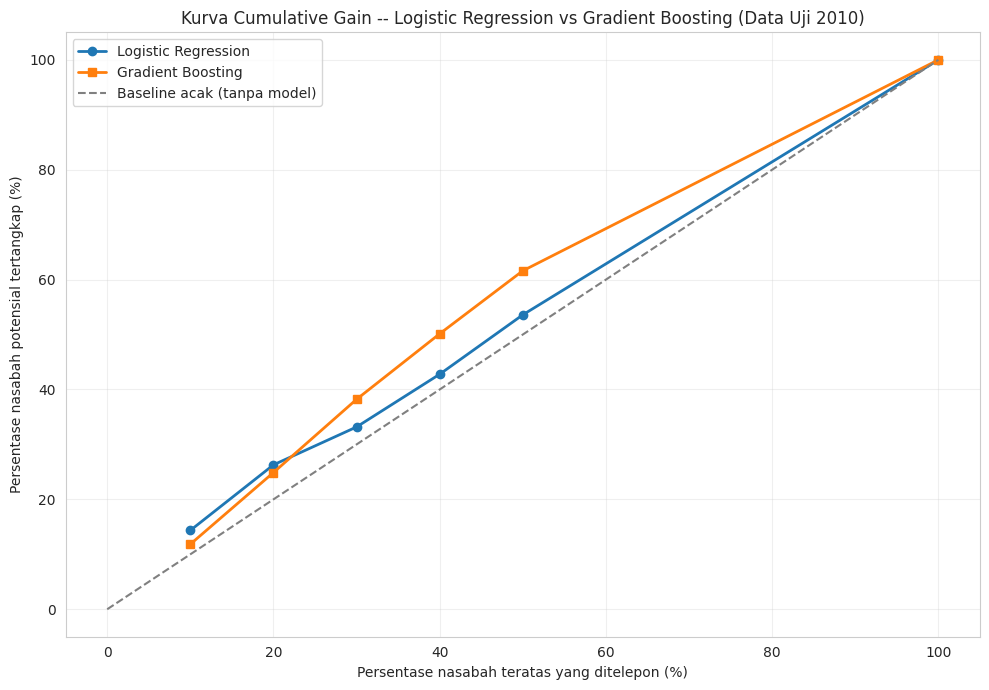

Titik silang perkiraan: antara top 20%-30%, GB mulai unggul dan bertahan hingga top 100%


In [35]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(lift_lr['top_pct'], lift_lr['pct_tertangkap'] * 100, marker='o', label='Logistic Regression', linewidth=2)
ax.plot(lift_gb['top_pct'], lift_gb['pct_tertangkap'] * 100, marker='s', label='Gradient Boosting', linewidth=2)
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Baseline acak (tanpa model)')

ax.set_xlabel('Persentase nasabah teratas yang ditelepon (%)')
ax.set_ylabel('Persentase nasabah potensial tertangkap (%)')
ax.set_title('Kurva Cumulative Gain -- Logistic Regression vs Gradient Boosting (Data Uji 2010)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Titik silang perkiraan: antara top 20%-30%, GB mulai unggul dan bertahan hingga top 100%")

### 6.7 Interpretasi Model

Menyajikan feature importance untuk Gradient Boosting (berbasis split pohon) dan koefisien untuk Logistic Regression (arah dan besaran pengaruh linear tiap fitur). Ini jadi bahan utama penyusunan rekomendasi -- tanpa tahap ini, kesimpulan hanya bisa menyebut skor model, tanpa menjelaskan tindakan apa yang sebaiknya diambil.

In [36]:
nama_fitur_encoded = model_gb_final.named_steps['preprocessor'].get_feature_names_out()

# Feature importance -- Gradient Boosting
importance_gb = pd.DataFrame({
    'fitur': nama_fitur_encoded,
    'importance': model_gb_final.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("=== Feature Importance -- Gradient Boosting (top 15) ===")
print(importance_gb.head(15).to_string(index=False))

# Koefisien -- Logistic Regression
koef_lr = pd.DataFrame({
    'fitur': nama_fitur_encoded,
    'koefisien': model_lr_final.named_steps['model'].coef_[0]
}).sort_values('koefisien', key=abs, ascending=False)

print("\n=== Koefisien -- Logistic Regression (top 15 berdasarkan besaran absolut) ===")
print(koef_lr.head(15).to_string(index=False))
print("\nCatatan: koefisien positif = mendorong prediksi subscribe, negatif = mendorong prediksi tidak subscribe")

=== Feature Importance -- Gradient Boosting (top 15) ===
                             fitur  importance
              scaler__emp_var_rate    0.426383
                 scaler__euribor3m    0.144951
             scaler__cons_conf_idx    0.099190
                       scaler__age    0.061068
                 onehot__month_oct    0.035528
          onehot__poutcome_success    0.033935
                  scaler__campaign    0.023641
   onehot__previously_contacted_ya    0.020667
                ordinal__education    0.018564
 onehot__pdays_bucket_belum_pernah    0.016722
            scaler__cons_price_idx    0.014266
onehot__previously_contacted_tidak    0.010812
           onehot__day_of_week_mon    0.010701
          onehot__poutcome_failure    0.008736
           onehot__day_of_week_wed    0.005886

=== Koefisien -- Logistic Regression (top 15 berdasarkan besaran absolut) ===
                             fitur  koefisien
              scaler__emp_var_rate  -3.458981
                 sca

## 7. Conclusion & Recommendation

### 7.1 Asumsi Ekonomi dan Pernyataan Keterbukaan

Dataset ini tidak memuat data biaya operasional maupun nilai produk. Angka biaya panggilan dan margin per term deposit pada bagian ini adalah **asumsi ilustratif** yang berfungsi memperlihatkan mekanisme perhitungan dampak, bukan angka aktual dari institusi manapun. Seluruh kesimpulan finansial berikut harus dibaca sebagai pernyataan bersyarat ("apabila asumsi ini berlaku, maka dampaknya sekian"), dan disajikan dalam tiga skenario -- bukan angka tunggal.

| Parameter | Skenario Rendah | Skenario Tengah | Skenario Tinggi | Dasar Penalaran |
|---|---|---|---|---|
| Biaya per panggilan | €5 | €3 | €2 | Mencakup waktu kerja agen dan biaya telekomunikasi |
| Margin per term deposit | €80 | €100 | €150 | Selisih bunga atas dana yang berhasil dihimpun |

Skenario rendah = kombinasi paling konservatif (biaya tertinggi, margin terendah); skenario tinggi = kombinasi paling optimis. Kapasitas call center diasumsikan tetap seperti kondisi saat ini -- tujuan rekomendasi adalah realokasi kapasitas, bukan pengurangan tenaga kerja.

In [37]:
SKENARIO = {
    'rendah': {'biaya_per_panggilan': 5, 'margin_per_deposit': 80},
    'tengah': {'biaya_per_panggilan': 3, 'margin_per_deposit': 100},
    'tinggi': {'biaya_per_panggilan': 2, 'margin_per_deposit': 150},
}

# Kondisi status quo: seluruh nasabah ditelepon (berdasarkan histori lengkap, 41.176 kontak)
total_panggilan_status_quo = len(df_clean)
total_subscribe_status_quo = df_clean['subscribed'].sum()

print(f"Status quo: {total_panggilan_status_quo} panggilan, {total_subscribe_status_quo} subscribe "
      f"({total_subscribe_status_quo/total_panggilan_status_quo:.2%})\n")

print("=== Nilai bisnis status quo (telepon semua nasabah) per skenario ===")
hasil_status_quo = []
for nama_skenario, param in SKENARIO.items():
    biaya_total = total_panggilan_status_quo * param['biaya_per_panggilan']
    pendapatan_total = total_subscribe_status_quo * param['margin_per_deposit']
    net_value = pendapatan_total - biaya_total
    hasil_status_quo.append({
        'skenario': nama_skenario, 'biaya_total': biaya_total,
        'pendapatan_total': pendapatan_total, 'net_value': net_value
    })
    print(f"{nama_skenario:8s}: biaya €{biaya_total:,.0f}, pendapatan €{pendapatan_total:,.0f}, "
          f"net value €{net_value:,.0f}")

Status quo: 41176 panggilan, 4639 subscribe (11.27%)

=== Nilai bisnis status quo (telepon semua nasabah) per skenario ===
rendah  : biaya €205,880, pendapatan €371,120, net value €165,240
tengah  : biaya €123,528, pendapatan €463,900, net value €340,372
tinggi  : biaya €82,352, pendapatan €695,850, net value €613,498


### 7.2 Kuantifikasi Dampak: Pembatasan Jumlah Panggilan

Mensimulasikan dampak finansial bila panggilan dihentikan setelah kontak ke-7 (sesuai Insight Q3). Asumsi simulasi: bagi nasabah yang baru subscribe pada panggilan ke-8 atau lebih, subscription tersebut dianggap tidak akan terjadi bila panggilan dihentikan di titik batas -- asumsi ini konservatif (kemungkinan sebagian dari mereka sebenarnya akan subscribe lebih awal bila ditelepon dengan pendekatan berbeda, tapi dari data historis kita tidak bisa memastikan itu).

In [38]:
CAP_PANGGILAN = 7

panggilan_dihemat = (df_clean['campaign'] - CAP_PANGGILAN).clip(lower=0).sum()
subscribe_hilang = df_clean.loc[
    (df_clean['campaign'] > CAP_PANGGILAN) & (df_clean['subscribed'] == 1)
].shape[0]

print(f"Dengan batas {CAP_PANGGILAN} panggilan per nasabah:")
print(f"  Panggilan yang dihemat : {panggilan_dihemat:,}")
print(f"  Subscription berpotensi hilang: {subscribe_hilang} dari {df_clean['subscribed'].sum()} total subscribe "
      f"({subscribe_hilang / df_clean['subscribed'].sum():.1%})")

print("\n=== Dampak finansial, per skenario ===")
for nama_skenario, param in SKENARIO.items():
    penghematan = panggilan_dihemat * param['biaya_per_panggilan']
    pendapatan_hilang = subscribe_hilang * param['margin_per_deposit']
    net_impact = penghematan - pendapatan_hilang
    print(f"{nama_skenario:8s}: hemat biaya €{penghematan:,.0f}, pendapatan berpotensi hilang €{pendapatan_hilang:,.0f}, "
          f"dampak bersih €{net_impact:,.0f}")

Dengan batas 7 panggilan per nasabah:
  Panggilan yang dihemat : 9,634
  Subscription berpotensi hilang: 73 dari 4639 total subscribe (1.6%)

=== Dampak finansial, per skenario ===
rendah  : hemat biaya €48,170, pendapatan berpotensi hilang €5,840, dampak bersih €42,330
tengah  : hemat biaya €28,902, pendapatan berpotensi hilang €7,300, dampak bersih €21,602
tinggi  : hemat biaya €19,268, pendapatan berpotensi hilang €10,950, dampak bersih €8,318


### 7.3 Kuantifikasi Dampak: Migrasi dari Telephone ke Cellular

Mensimulasikan dampak bila seluruh panggilan lewat `telephone` dialihkan ke `cellular`. Karena kita tidak punya data biaya per channel (dataset tidak membedakan tarif cellular vs telephone), asumsi yang dipakai: biaya per panggilan sama untuk kedua channel, dan dampak utamanya datang dari selisih conversion rate. Selisih ini dihitung di dalam tahun yang sama lalu dijumlahkan antar tahun -- bukan dari rata-rata keseluruhan -- karena komposisi panggilan telephone sangat timpang antar periode (91% dari seluruh panggilan telephone terjadi di 2008, tahun dengan conversion rate terendah), sehingga rata-rata mentah akan mencampur efek channel dengan efek periode.

In [39]:
print("Conversion rate dan n per tahun, per channel:")
print(df_clean.groupby(['year', 'contact'])['subscribed'].agg(['mean', 'size']).unstack().round(4))

subscribe_tambahan_potensial = 0
print("\n=== Estimasi tambahan subscription bila dialihkan ke cellular, dikontrol per tahun ===")
for yr in sorted(df_clean['year'].unique()):
    rate_cell_yr = df_clean.loc[(df_clean['year'] == yr) & (df_clean['contact'] == 'cellular'), 'subscribed'].mean()
    rate_tel_yr = df_clean.loc[(df_clean['year'] == yr) & (df_clean['contact'] == 'telephone'), 'subscribed'].mean()
    n_tel_yr = ((df_clean['year'] == yr) & (df_clean['contact'] == 'telephone')).sum()
    tambahan_yr = n_tel_yr * (rate_cell_yr - rate_tel_yr)
    subscribe_tambahan_potensial += tambahan_yr
    print(f"  {yr}: cellular={rate_cell_yr:.4f}, telephone={rate_tel_yr:.4f}, "
          f"n_telephone={n_tel_yr}, tambahan={tambahan_yr:.1f}")

print(f"\nTotal estimasi tambahan subscription (dikontrol per tahun): {subscribe_tambahan_potensial:.0f}")

print("\n=== Dampak finansial, per skenario (hanya dari sisi pendapatan tambahan) ===")
for nama_skenario, param in SKENARIO.items():
    pendapatan_tambahan = subscribe_tambahan_potensial * param['margin_per_deposit']
    print(f"{nama_skenario:8s}: potensi pendapatan tambahan €{pendapatan_tambahan:,.0f}")

print("\nCatatan: tidak ada biaya tambahan diasumsikan untuk migrasi channel (di luar cakupan data).")

Conversion rate dan n per tahun, per channel:
            mean               size          
contact cellular telephone cellular telephone
year                                         
2008      0.0573    0.0393    13970     13712
2009      0.1990    0.1467    10495       941
2010      0.5766    0.2835     1670       388

=== Estimasi tambahan subscription bila dialihkan ke cellular, dikontrol per tahun ===
  2008: cellular=0.0573, telephone=0.0393, n_telephone=13712, tambahan=246.2
  2009: cellular=0.1990, telephone=0.1467, n_telephone=941, tambahan=49.3
  2010: cellular=0.5766, telephone=0.2835, n_telephone=388, tambahan=113.7

Total estimasi tambahan subscription (dikontrol per tahun): 409

=== Dampak finansial, per skenario (hanya dari sisi pendapatan tambahan) ===
rendah  : potensi pendapatan tambahan €32,741
tengah  : potensi pendapatan tambahan €40,927
tinggi  : potensi pendapatan tambahan €61,390

Catatan: tidak ada biaya tambahan diasumsikan untuk migrasi channel (di luar cakup

### 7.4 Kuantifikasi Dampak: Call List Terprioritas Lewat Model

Mensimulasikan dampak bila hanya top-N% nasabah (berdasarkan skor Gradient Boosting, yang terbukti unggul di top 30% ke atas pada kurva lift) yang ditelepon, dibandingkan status quo menelepon semua nasabah. Disimulasikan pada data uji 2010 sebagai representasi kondisi nyata.

In [40]:
print("=== Dampak panggilan selektif (top-N%) vs status quo (telepon semua), data uji 2010 ===\n")

total_panggilan_test = len(test_df)
total_subscribe_test = y_test.sum()

for top_pct in [20, 30, 50]:
    baris_lift = lift_gb[lift_gb['top_pct'] == top_pct].iloc[0]
    n_ditelepon = baris_lift['n_ditelepon']
    n_tertangkap = baris_lift['n_tertangkap']
    n_terlewat = total_subscribe_test - n_tertangkap
    panggilan_dihemat = total_panggilan_test - n_ditelepon

    print(f"--- Top {top_pct}% (n={n_ditelepon} ditelepon, {panggilan_dihemat} dihemat) ---")
    print(f"  Subscription tertangkap: {n_tertangkap} dari {total_subscribe_test} ({n_tertangkap/total_subscribe_test:.1%})")
    print(f"  Subscription terlewat  : {n_terlewat}")
    for nama_skenario, param in SKENARIO.items():
        penghematan = panggilan_dihemat * param['biaya_per_panggilan']
        pendapatan_hilang = n_terlewat * param['margin_per_deposit']
        net_impact = penghematan - pendapatan_hilang
        print(f"    {nama_skenario:8s}: hemat €{penghematan:,.0f}, pendapatan hilang €{pendapatan_hilang:,.0f}, "
              f"dampak bersih €{net_impact:,.0f}")
    print()

=== Dampak panggilan selektif (top-N%) vs status quo (telepon semua), data uji 2010 ===

--- Top 20% (n=411 ditelepon, 1647 dihemat) ---
  Subscription tertangkap: 267 dari 1073 (24.9%)
  Subscription terlewat  : 806
    rendah  : hemat €8,235, pendapatan hilang €64,480, dampak bersih €-56,245
    tengah  : hemat €4,941, pendapatan hilang €80,600, dampak bersih €-75,659
    tinggi  : hemat €3,294, pendapatan hilang €120,900, dampak bersih €-117,606

--- Top 30% (n=617 ditelepon, 1441 dihemat) ---
  Subscription tertangkap: 410 dari 1073 (38.2%)
  Subscription terlewat  : 663
    rendah  : hemat €7,205, pendapatan hilang €53,040, dampak bersih €-45,835
    tengah  : hemat €4,323, pendapatan hilang €66,300, dampak bersih €-61,977
    tinggi  : hemat €2,882, pendapatan hilang €99,450, dampak bersih €-96,568

--- Top 50% (n=1029 ditelepon, 1029 dihemat) ---
  Subscription tertangkap: 661 dari 1073 (61.6%)
  Subscription terlewat  : 412
    rendah  : hemat €5,145, pendapatan hilang €32,960,

Hasil di atas negatif karena kondisi 2010 (conversion rate sudah tinggi, 52%) membuat strategi selektif merugi -- bahkan kelompok skor terendah pun masih sering convert. Diuji ulang asumsi ini: apakah strategi selektif justru menguntungkan pada kondisi conversion rendah seperti 2008-2009, memakai skor model yang sama (dilatih pada data yang sama, dievaluasi lewat cross-validation).

In [41]:
from sklearn.model_selection import cross_val_predict

proba_train_cv = cross_val_predict(
    model_gb_final, X_train_raw, y_train, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

lift_train = hitung_cumulative_gain(y_train, proba_train_cv, 'Gradient Boosting (data latih, out-of-fold)')
print("Kurva lift pada data latih 2008-2009 (conversion rate rendah):")
print(lift_train[['top_pct', 'n_ditelepon', 'n_tertangkap', 'pct_tertangkap']].to_string(index=False))

total_panggilan_train = len(train_df)
total_subscribe_train = y_train.sum()

print(f"\n=== Dampak panggilan selektif vs status quo, data latih 2008-2009 (conversion {total_subscribe_train/total_panggilan_train:.1%}) ===\n")
for top_pct in [20, 30, 50]:
    baris_lift = lift_train[lift_train['top_pct'] == top_pct].iloc[0]
    n_ditelepon = baris_lift['n_ditelepon']
    n_tertangkap = baris_lift['n_tertangkap']
    n_terlewat = total_subscribe_train - n_tertangkap
    panggilan_dihemat = total_panggilan_train - n_ditelepon

    print(f"--- Top {top_pct}% (n={n_ditelepon} ditelepon, {panggilan_dihemat} dihemat) ---")
    print(f"  Subscription tertangkap: {n_tertangkap} dari {total_subscribe_train} ({n_tertangkap/total_subscribe_train:.1%})")
    for nama_skenario, param in SKENARIO.items():
        penghematan = panggilan_dihemat * param['biaya_per_panggilan']
        pendapatan_hilang = n_terlewat * param['margin_per_deposit']
        net_impact = penghematan - pendapatan_hilang
        print(f"    {nama_skenario:8s}: hemat €{penghematan:,.0f}, pendapatan hilang €{pendapatan_hilang:,.0f}, "
              f"dampak bersih €{net_impact:,.0f}")
    print()

Kurva lift pada data latih 2008-2009 (conversion rate rendah):
 top_pct  n_ditelepon  n_tertangkap  pct_tertangkap
      10         3911          1568        0.439708
      20         7823          2071        0.580763
      30        11735          2370        0.664610
      40        15647          2625        0.736119
      50        19559          2828        0.793045
     100        39118          3566        1.000000

=== Dampak panggilan selektif vs status quo, data latih 2008-2009 (conversion 9.1%) ===

--- Top 20% (n=7823 ditelepon, 31295 dihemat) ---
  Subscription tertangkap: 2071 dari 3566 (58.1%)
    rendah  : hemat €156,475, pendapatan hilang €119,600, dampak bersih €36,875
    tengah  : hemat €93,885, pendapatan hilang €149,500, dampak bersih €-55,615
    tinggi  : hemat €62,590, pendapatan hilang €224,250, dampak bersih €-161,660

--- Top 30% (n=11735 ditelepon, 27383 dihemat) ---
  Subscription tertangkap: 2370 dari 3566 (66.5%)
    rendah  : hemat €136,915, pendapatan

Perbedaan arah hasil antar skenario (positif di skenario rendah, negatif di tengah dan tinggi) dijelaskan oleh titik impas: kelompok nasabah layak dilewati hanya bila conversion rate-nya di bawah rasio biaya/margin skenario tersebut. Dihitung eksplisit untuk melengkapi analisis sensitivitas.

In [42]:
print("=== Titik impas (breakeven conversion rate) per skenario ===")
for nama_skenario, param in SKENARIO.items():
    breakeven = param['biaya_per_panggilan'] / param['margin_per_deposit']
    print(f"  {nama_skenario:8s}: biaya/margin = {param['biaya_per_panggilan']}/{param['margin_per_deposit']} = {breakeven:.2%}")

print("\n=== Conversion rate kelompok yang DILEWATI (bottom N%), data latih 2008-2009 ===")
for top_pct in [20, 30, 50]:
    baris_lift = lift_train[lift_train['top_pct'] == top_pct].iloc[0]
    n_dilewati = total_panggilan_train - baris_lift['n_ditelepon']
    subscribe_dilewati = total_subscribe_train - baris_lift['n_tertangkap']
    rate_dilewati = subscribe_dilewati / n_dilewati
    print(f"  Bottom {100-top_pct}% (n={n_dilewati}): conversion rate = {rate_dilewati:.2%}")

=== Titik impas (breakeven conversion rate) per skenario ===
  rendah  : biaya/margin = 5/80 = 6.25%
  tengah  : biaya/margin = 3/100 = 3.00%
  tinggi  : biaya/margin = 2/150 = 1.33%

=== Conversion rate kelompok yang DILEWATI (bottom N%), data latih 2008-2009 ===
  Bottom 80% (n=31295): conversion rate = 4.78%
  Bottom 70% (n=27383): conversion rate = 4.37%
  Bottom 50% (n=19559): conversion rate = 3.77%


### 7.5 Rangkuman Rekomendasi Final

| No | Rekomendasi | Dasar Temuan | Estimasi Dampak (skenario tengah) | Keberlakuan |
|---|---|---|---|---|
| 1 | Batasi panggilan maksimum 7 kali per nasabah, alihkan kapasitas ke prospek baru | Conversion turun dari 13,04% (panggilan ke-1) menjadi 4,25% (panggilan ke-8); tren negatif terbukti signifikan (Cochran-Armitage Z=-14,02, p<0,001) | +€21.602 (hemat 9.634 panggilan, 73 subscription berisiko hilang) | **Kuat** -- dampak bersih positif di ketiga skenario |
| 2 | Hentikan telephone, migrasi penuh ke cellular | Cellular unggul di semua kombinasi usia/pekerjaan yang diuji (rasio 2,1x-3,4x); konsisten di tiga tahun | +€40.927 (409 subscription tambahan, dikontrol per tahun) | **Kuat** -- dampak bersih positif di ketiga skenario, arah konsisten 3 tahun |
| 3 | Sesuaikan intensitas kampanye mengikuti suku bunga acuan, diperbesar saat suku bunga rendah | Conversion naik ~11x dari 2008 (4,84%) ke 2010 (52,14%), korelasi conversion-euribor antar kuartal -0,886; `emp_var_rate` + `euribor3m` + indikator makro lain menyumbang 68% feature importance model | Tidak dikuantifikasi dalam satuan uang -- bersifat arahan strategis, bukan aksi tunggal | **Kuat**, dan merupakan temuan paling jarang muncul pada analisis lain atas dataset ini |
| 4 | Susun call list berdasarkan skor model (Gradient Boosting), bukan ditelepon semua | Kurva lift: top 30-50% menangkap 38-62% subscription potensial saat conversion rendah (2008-2009) | Bervariasi tajam: +€41.235 (skenario rendah, top 30%) hingga -€161.660 (skenario tinggi, top 20%) | **Kondisional** -- bergantung pada rasio biaya/margin (breakeven 1,33%-6,25%) DAN kondisi conversion rate periode berjalan, bukan aturan permanen |
| 5 | Prioritaskan nasabah usia 60+ dan riwayat poutcome=success | Usia 60+ selalu peringkat #1 di 3 tahun (arah robust, besaran kondisional); poutcome=success unggul 56,3 poin dari nonexistent | Tidak dikuantifikasi terpisah -- sudah tercakup dalam skor model pada rekomendasi #4 | **Robust pada arah, kondisional pada besaran** |

**Catatan khusus Rekomendasi #4:** berbeda dari tiga rekomendasi lain yang konsisten positif di semua skenario ekonomi, dampak call list selektif berubah arah tergantung rasio biaya/margin yang diasumsikan -- pada margin besar (skenario tinggi), melewatkan nasabah berisiko tinggi jadi lebih mahal daripada menelepon semua orang. Ini bukan kelemahan model, melainkan sifat matematis dari ekonomi keputusan: strategi selektif hanya masuk akal ketika kelompok yang dilewati conversion rate-nya di bawah titik impas biaya/margin saat itu.

### Mencari Titik Aman Lintas Kondisi untuk Call List Selektif

Menguji seluruh kombinasi top-% dan skenario ekonomi pada kedua periode (2008-2009 dan 2010) sekaligus, untuk melihat apakah ada satu rekomendasi top-% yang tetap menguntungkan terlepas dari kondisi suku bunga yang sedang berlangsung.

In [43]:
def hitung_net_impact(lift_df, total_panggilan, total_subscribe, top_pct, param):
    baris = lift_df[lift_df['top_pct'] == top_pct].iloc[0]
    n_ditelepon = baris['n_ditelepon']
    n_tertangkap = baris['n_tertangkap']
    n_terlewat = total_subscribe - n_tertangkap
    panggilan_dihemat = total_panggilan - n_ditelepon
    penghematan = panggilan_dihemat * param['biaya_per_panggilan']
    pendapatan_hilang = n_terlewat * param['margin_per_deposit']
    return penghematan - pendapatan_hilang

hasil_gabungan = []
for top_pct in [10, 20, 30, 40, 50]:
    for nama_skenario, param in SKENARIO.items():
        net_2008_2009 = hitung_net_impact(lift_train, total_panggilan_train, total_subscribe_train, top_pct, param)
        net_2010 = hitung_net_impact(lift_gb, total_panggilan_test, total_subscribe_test, top_pct, param)
        aman_lintas_kondisi = (net_2008_2009 > 0) and (net_2010 > 0)
        hasil_gabungan.append({
            'top_pct': top_pct, 'skenario': nama_skenario,
            'net_2008_2009': round(net_2008_2009), 'net_2010': round(net_2010),
            'aman_lintas_kondisi': aman_lintas_kondisi
        })

df_gabungan = pd.DataFrame(hasil_gabungan)
print(df_gabungan.to_string(index=False))

n_aman = df_gabungan['aman_lintas_kondisi'].sum()
print(f"\nJumlah kombinasi yang positif di KEDUA periode sekaligus: {n_aman} dari {len(df_gabungan)}")
if n_aman > 0:
    print(df_gabungan[df_gabungan['aman_lintas_kondisi']])

 top_pct skenario  net_2008_2009  net_2010  aman_lintas_kondisi
      10   rendah          16195    -66415                False
      10   tengah         -94179    -89041                False
      10   tinggi        -229286   -138194                False
      20   rendah          36875    -56245                False
      20   tengah         -55615    -75659                False
      20   tinggi        -161660   -117606                False
      30   rendah          41235    -45835                False
      30   tengah         -37451    -61977                False
      30   tinggi        -124634    -96568                False
      40   rendah          42075    -36625                False
      40   tengah         -23687    -49795                False
      40   tinggi         -94208    -77780                False
      50   rendah          38755    -27815                False
      50   tengah         -15123    -38113                False
      50   tinggi         -71582    -597

**Pembaruan Rekomendasi #4:** pengujian menyeluruh pada 15 kombinasi top-% x skenario menunjukkan **nol** kombinasi yang menguntungkan secara bersamaan di kondisi conversion rendah (2008-2009) maupun tinggi (2010). Ini bukan sekadar soal besaran dampak yang bervariasi, melainkan arah untung-rugi yang bisa terbalik sepenuhnya tergantung fase suku bunga yang sedang berlangsung. Rekomendasi operasionalnya karenanya menjadi dua langkah, bukan satu aturan tetap:

1. **Pantau conversion rate dasar periode berjalan** (atau proksinya: level suku bunga acuan) sebagai pemicu keputusan.
2. **Terapkan call list selektif berbasis skor model hanya saat conversion rate dasar sedang rendah** (mendekati kondisi 2008-2009); **saat conversion rate dasar sudah tinggi** (mendekati kondisi 2010), hentikan penyaringan dan **telepon seluruh nasabah** -- penyaringan justru merugikan secara ekonomi pada kondisi tersebut.

Dengan kata lain: model prediksi tetap berguna sepanjang waktu untuk **mengurutkan prioritas**, tapi keputusan **memakai skor itu untuk memangkas call list** harus mengikuti kondisi makro saat itu -- ini justru penerapan konkret dari Rekomendasi #3 (sesuaikan intensitas mengikuti suku bunga), bukan rekomendasi yang berdiri sendiri.

### 7.6 Keterbatasan Analisis

- **Tidak tersedia client ID**, sehingga analisis tidak bisa menelusuri perilaku nasabah yang sama di lintas kampanye atau membangun fitur riwayat jangka panjang per individu.
- **Periode data berakhir November 2010**, mencakup masa krisis keuangan global dengan suku bunga yang jatuh drastis -- pola yang kita temukan (dominasi indikator makro, migrasi channel) mungkin tidak serta-merta berlaku pada kondisi ekonomi yang berbeda (misalnya periode suku bunga naik atau stabil).
- **Observasi 2010 relatif kecil** (2.058 baris berbanding 39.118 di 2008-2009), sehingga seluruh temuan yang spesifik untuk tahun tersebut -- termasuk breakeven call list selektif -- punya ketidakpastian lebih besar dibanding temuan dari dua tahun sebelumnya.
- **Model tidak diuji pada kondisi suku bunga di luar rentang data latih** (year 2010 sudah di luar rentang 2008-2009 yang dilihat model saat training) -- performa model pada kondisi makro yang benar-benar baru (bukan sekadar lanjutan tren yang sudah terlihat) belum tentu seakurat yang terukur di sini.
- **Angka dampak finansial sepenuhnya bergantung pada asumsi ilustratif** (biaya panggilan €2-5, margin €80-150) yang diadaptasi dari panduan, bukan data biaya aktual institusi manapun -- rekomendasi kuantitatif pada bagian ini harus dibaca sebagai demonstrasi mekanisme, bukan angka final untuk pengambilan keputusan nyata.
- **Kolom `duration` sengaja dikeluarkan dari model** meski punya korelasi tertinggi terhadap label -- trade-off yang disengaja demi menghindari data leakage, tapi berarti model tidak memanfaatkan sinyal real-time yang sebenarnya paling informatif saat panggilan sedang berlangsung.

### 7.7 Ekspor Hasil Final

In [44]:
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Purwadhika_FinPro/output'

# Skor probabilitas seluruh nasabah (data uji 2010) untuk kebutuhan dashboard/call list
scored_clients = test_df[['age', 'job', 'contact', 'poutcome', 'year']].copy()
scored_clients['skor_probabilitas'] = proba_gb
scored_clients['desil'] = pd.qcut(scored_clients['skor_probabilitas'], 10, labels=False, duplicates='drop') + 1
scored_clients['subscribed_actual'] = y_test
scored_clients = scored_clients.sort_values('skor_probabilitas', ascending=False).reset_index(drop=True)
scored_clients.to_csv(f'{OUTPUT_DIR}/scored_clients.csv', index=False)
print(f"scored_clients.csv tersimpan -- {scored_clients.shape[0]} baris")

# Tabel rekomendasi final
tabel_rekomendasi_final = pd.DataFrame([
    {'no': 1, 'rekomendasi': 'Batas maksimum 7 panggilan per nasabah',
     'dampak_skenario_tengah': 21602, 'keberlakuan': 'Kuat'},
    {'no': 2, 'rekomendasi': 'Migrasi penuh telephone ke cellular',
     'dampak_skenario_tengah': 40927, 'keberlakuan': 'Kuat'},
    {'no': 3, 'rekomendasi': 'Sesuaikan intensitas kampanye mengikuti suku bunga',
     'dampak_skenario_tengah': None, 'keberlakuan': 'Kuat (arahan strategis)'},
    {'no': 4, 'rekomendasi': 'Call list berbasis skor model, hanya saat conversion rate dasar rendah',
     'dampak_skenario_tengah': None, 'keberlakuan': 'Kondisional terhadap fase suku bunga'},
    {'no': 5, 'rekomendasi': 'Prioritaskan usia 60+ dan poutcome=success',
     'dampak_skenario_tengah': None, 'keberlakuan': 'Robust pada arah, kondisional pada besaran'},
])
tabel_rekomendasi_final.to_csv(f'{OUTPUT_DIR}/rekomendasi_final.csv', index=False)
print("rekomendasi_final.csv tersimpan")

print("\n=== Ringkasan akhir seluruh notebook ===")
print(f"Data bersih     : {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")
print(f"Model final     : Gradient Boosting (PR-AUC CV: {search_gb.best_score_:.4f})")
print(f"Model pembanding: Logistic Regression (PR-AUC CV: {search_lr.best_score_:.4f})")
print(f"Jumlah rekomendasi final: {len(tabel_rekomendasi_final)}")

scored_clients.csv tersimpan -- 2058 baris
rekomendasi_final.csv tersimpan

=== Ringkasan akhir seluruh notebook ===
Data bersih     : 41176 baris x 29 kolom
Model final     : Gradient Boosting (PR-AUC CV: 0.3532)
Model pembanding: Logistic Regression (PR-AUC CV: 0.3376)
Jumlah rekomendasi final: 5


## 8. Save Model

### 8.1 Refit Model Final pada Seluruh Data

Model Gradient Boosting (hasil tuning) sejauh ini hanya dilatih pada data 2008-2009 untuk keperluan evaluasi temporal split yang adil. Untuk deployment, model dilatih ulang pada seluruh data (2008-2010) dengan hyperparameter yang sama, supaya memanfaatkan seluruh informasi yang ada -- termasuk pola dari kondisi 2010 yang paling relevan dengan kondisi terkini.

In [45]:
from sklearn.base import clone

final_pipeline = clone(model_gb_final)
final_pipeline.fit(df_clean[FEATURE_COLS], df_clean['subscribed'])

pred_full = final_pipeline.predict_proba(df_clean[FEATURE_COLS])[:, 1]
print(f"PR-AUC pada seluruh data (in-sample, bukan pembanding objektif): "
      f"{average_precision_score(df_clean['subscribed'], pred_full):.4f}")
print("Catatan: angka ini wajar lebih tinggi dari skor CV/temporal split karena model "
      "dievaluasi pada data yang sama yang dipakai untuk melatihnya -- bukan ukuran "
      "performa yang objektif, hanya pengecekan bahwa model berhasil di-refit dengan benar.")

PR-AUC pada seluruh data (in-sample, bukan pembanding objektif): 0.5249
Catatan: angka ini wajar lebih tinggi dari skor CV/temporal split karena model dievaluasi pada data yang sama yang dipakai untuk melatihnya -- bukan ukuran performa yang objektif, hanya pengecekan bahwa model berhasil di-refit dengan benar.


### 8.2 Pickle Model

In [46]:
import pickle as pkl
import json

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Purwadhika_FinPro/output'

model_path = f'{OUTPUT_DIR}/final_model_gradient_boosting.pkl'
with open(model_path, 'wb') as f:
    pkl.dump(final_pipeline, f)

meta_path = f'{OUTPUT_DIR}/model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump({
        'feature_cols': FEATURE_COLS,
        'model_type': 'GradientBoostingClassifier',
        'best_params': {k.replace('model__', ''): v for k, v in search_gb.best_params_.items()},
        'pr_auc_cv': float(search_gb.best_score_),
        'pr_auc_temporal_test_2010': float(average_precision_score(y_test, proba_gb)),
        'catatan': 'Fitur duration sengaja tidak disertakan karena leakage. '
                   'Ambang batas 0.5 tidak disarankan -- gunakan skor probabilitas '
                   'untuk ranking/kurva lift, bukan klasifikasi langsung.',
    }, f, indent=2)

print(f"Model disimpan ke: {model_path}")
print(f"Metadata disimpan ke: {meta_path}")

Model disimpan ke: /content/drive/MyDrive/Colab Notebooks/Purwadhika_FinPro/output/final_model_gradient_boosting.pkl
Metadata disimpan ke: /content/drive/MyDrive/Colab Notebooks/Purwadhika_FinPro/output/model_metadata.json
